## Libraries and configuration

In [120]:
import numpy as np
import pandas as pd
import yfinance as yf
import xgboost as xgb
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from jumpmodels.sparse_jump import SparseJumpModel
import sys
import warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from utils.plotting import (
    plot_cumulative_returns, plot_drawdown, plot_rolling_sharpe,
    plot_rolling_volatility, plot_sharpe_bar, plot_performance_summary,
    plot_correlation_heatmap, plot_weights_heatmap, plot_weights_area,
    plot_regime_detection
)

# ===========================
# CONFIGURATION
# ===========================
TICKERS = ['NVDA', 'GOOGL', 'AAPL', 'MSFT', 'AMZN', 'AVGO', 'META', 'TSLA', 
           'WMT', 'JPM', 'LLY', 'XOM', 'V', 'MU', 'AMD', 'JNJ', 'INTC', 'ORCL', 
           'MA', 'COST', 'NFLX', 'CVX', 'BAC', 'CAT', 'ABBV', 'CSCO', 'PG', 'KO', 
           'UNH', 'HD', 'LRCX', 'AMAT', 'GE', 'MS', 'MRK', 'GS', 'PM', 'WFC', 'TXN', 'KLAC', 'LIN', 'RTX', 'C', 'AXP']
START_DATE = '2014-01-01'
END_DATE   = '2026-01-01'
TRAIN_WINDOW_MONTHS = 36          # rolling training window (months)
RISK_AVERSION = 2.5               # lambda in mean-variance utility
SHRINK_FACTOR = 0.25              # weight on prior (0 = raw XGB, 1 = prior)
PRIOR_TYPE = 'cross_mean'         # 'cross_mean', 'zero', 'historical_mean'
TURNOVER_PENALTY = 0.01           # per unit L1 change from previous weights
LOOKBACK_COV = 12                 # months for covariance estimation
RISK_FREE_RATE = 0.04             # annualized risk-free rate (e.g. 0.04 = 4%)

ImportError: cannot import name 'plot_regime_detection' from 'utils.plotting' (d:\Development\Projects\BSc_Thesis\utils\plotting.py)

## Regime detection codeblock

In [ ]:
# ========================
# STEP Data Preparation
# ========================
def prepare_market_data(ticker: str, start_date: str, end_date: str):
    """
    Download data and create regime detection features
    Returns: X (features) and raw returns for visualization
    """
    data = yf.download(ticker, start=start_date, end=end_date)
    returns = data['Close'].pct_change().dropna()
    
    # Build feature set for regime detection
    features = pd.DataFrame(index=returns.index)
    # Price momentum features
    features['momentum_5d'] = returns.rolling(5).mean()
    features['momentum_20d'] = returns.rolling(20).mean()
    # Volatility features
    features['volatility_5d'] = returns.rolling(5).std()
    features['volatility_20d'] = returns.rolling(20).std()
    # Additional features
    features['skewness'] = returns.rolling(20).skew()
    features['kurtosis'] = returns.rolling(20).kurt()
    # Volume features
    features['volume_change'] = data['Volume'].pct_change()
    features['volume_trend'] = data['Volume'].rolling(5).mean() / data['Volume'].rolling(20).mean()
    
    # Remove NaN values
    features = features.dropna()
    
    return features, returns.loc[features.index]

# Load S&P 500 data
ticker = "^SPX"
features, returns = prepare_market_data(ticker, "2020-01-01", "2024-03-01")
print(f"Features shape: {features.shape}")

# ========================
# STEP 2: Define SJM Parameters
# ========================
n_regimes = 3                     # Bull (2), Bear (0), Crab/Neutral (1)
lambda_param = 0.5               # Penalty for regime switching
max_iterations = 100             # Maximum optimization iterations
tolerance = 1e-4                 # Convergence tolerance

sjm = SparseJumpModel(
    n_regimes=n_regimes,
    lambda_=lambda_param,
    max_iter=max_iterations,
    tol=tolerance
)

# ========================
# STEP 3: Training & Prediction
# ========================
sjm.fit(features)
regime_labels = sjm.predict()

# Get regime probabilities
regime_probabilities = sjm.predict_proba()

# ========================
# STEP 4: Map Clusters to Regime Types
# ========================
# SJM returns numeric labels; we map them to bull/crab/bear
def map_labels_to_regimes(regime_labels, returns):
    """
    Map numeric regime labels (0,1,2) to market regimes based on returns
    """
    regime_returns = returns.groupby(regime_labels).mean()
    sorted_regimes = regime_returns.sort_values().index
    regime_map = {
        sorted_regimes[0]: 'Bear',
        sorted_regimes[1]: 'Crab',
        sorted_regimes[2]: 'Bull'
    }
    return pd.Series(regime_labels).map(regime_map).values

regime_types = map_labels_to_regimes(regime_labels, returns)

# ========================
# STEP 5: Visualization
# ========================
plot_regime_detection(
    returns,
    regime_types,
    title='Market Regimes — Sparse Jump Model',
)

# ========================
# STEP 6: Performance Metrics
# ========================
def calculate_regime_metrics(returns, regime_labels):
    metrics = {}
    for regime in np.unique(regime_labels):
        regime_returns = returns[regime_labels == regime]
        metrics[regime] = {
            'Count': len(regime_returns),
            'Mean Daily Return': regime_returns.mean(),
            'Volatility': regime_returns.std(),
            'Sharpe': regime_returns.mean() / regime_returns.std() if regime_returns.std() > 0 else 0,
            'Max Drawdown': (regime_returns.cumsum().min())
        }
    return pd.DataFrame(metrics).T

print(calculate_regime_metrics(returns, regime_types))

[*********************100%***********************]  1 of 1 completed

Features shape: (1027, 8)


NameError: name 'SparseJumpModel' is not defined

## Main backtesting code block

In [101]:
# ===========================
# DATA FETCHING & FEATURE ENGINEERING
# ===========================
def fetch_and_engineer_features(tickers, start, end):
    """
    Download price/volume data and compute a wide set of characteristics.
    Returns a DataFrame with MultiIndex (Date, ticker).
    """
    data = yf.download(tickers, start=start, end=end, group_by='ticker', auto_adjust=False)
    adj_close = pd.DataFrame({ticker: data[ticker]['Adj Close'] for ticker in tickers})
    volume = pd.DataFrame({ticker: data[ticker]['Volume'] for ticker in tickers})
    
    daily_returns = adj_close.pct_change().dropna(how='all')
    monthly_close = adj_close.resample('ME').last()
    monthly_volume = volume.resample('ME').sum()
    monthly_returns = monthly_close.pct_change().dropna(how='all')
    
    all_features = []
    
    for ticker in tickers:
        prices = monthly_close[ticker]
        vol_monthly = monthly_volume[ticker]
        daily_ret_ticker = daily_returns[ticker].dropna()
        
        # Create DataFrame with month-end index
        df = pd.DataFrame(index=prices.index)
        df['ticker'] = ticker
        df['price'] = prices
        df['volume'] = vol_monthly
        
        # 1. Momentum
        df['mom_3m']  = (prices / prices.shift(3) - 1)
        df['mom_6m']  = (prices / prices.shift(6) - 1)
        df['mom_12m'] = (prices / prices.shift(12) - 1)
        
        # 2. Volatility (annualized from daily returns over past 21 days)
        daily_vol = daily_ret_ticker.rolling(21).std() * np.sqrt(252)
        monthly_vol = daily_vol.resample('ME').last()
        df['vol_21d'] = monthly_vol.reindex(df.index).ffill()
        
        # 3. Idiosyncratic volatility proxy (CAPM residual vol)
        market_daily = daily_returns.mean(axis=1).dropna()
        if len(daily_ret_ticker) > 21:
            common = daily_ret_ticker.index.intersection(market_daily.index)
            if len(common) > 21:
                resid_vol = []
                resid_dates = []
                for date in common[20:]:
                    slice_ret = daily_ret_ticker.loc[date - pd.Timedelta(days=30):date]
                    slice_mkt = market_daily.loc[date - pd.Timedelta(days=30):date]
                    if len(slice_ret) >= 21:
                        _, resid = np.polyfit(slice_mkt, slice_ret, 1)
                        resid_vol.append(np.std(slice_ret - resid))
                        resid_dates.append(date)
                if resid_dates:
                    resid_vol_series = pd.Series(resid_vol, index=resid_dates)
                    monthly_resid = resid_vol_series.resample('ME').last()
                    df['idiosyncratic_vol'] = monthly_resid.reindex(df.index).ffill()
        
        # 4. Max daily return in past month
        max_daily = daily_ret_ticker.rolling(21).max()
        monthly_max = max_daily.resample('ME').last()
        df['max_daily_ret'] = monthly_max.reindex(df.index).ffill()
        
        # 5. Volume trend (12-month change)
        df['volume_trend'] = (vol_monthly / vol_monthly.shift(12) - 1)
        
        # 6. Amihud illiquidity proxy
        dollar_volume = volume[ticker] * adj_close[ticker]
        amihud = (daily_ret_ticker.abs() / dollar_volume).rolling(21).mean()
        monthly_amihud = amihud.resample('ME').last()
        df['amihud_illiq'] = monthly_amihud.reindex(df.index).ffill()
        
        # 7. Fundamentals (from yfinance info - latest available, forward filled)
        info = yf.Ticker(ticker).info
        eps = info.get('trailingEps', np.nan)
        if eps and eps > 0:
            df['ep_ratio'] = eps / df['price']
        else:
            df['ep_ratio'] = np.nan
        
        debt_to_eq = info.get('debtToEquity', np.nan)
        df['debt_to_equity'] = debt_to_eq / 100.0 if debt_to_eq else np.nan
        
        roe = info.get('returnOnEquity', np.nan)
        df['roe'] = roe if roe else np.nan
        
        revenue_growth = info.get('revenueGrowth', np.nan)
        df['asset_growth_proxy'] = revenue_growth if revenue_growth else np.nan
        
        market_cap = info.get('marketCap', np.nan)
        df['size'] = np.log(market_cap) if market_cap and market_cap > 0 else np.nan
        
        # 8. Seasonality: month
        df['month'] = df.index.month
        
        # 9. Rolling window aggregates
        for col in ['mom_6m', 'vol_21d', 'size', 'ep_ratio']:
            if col in df.columns:
                for window in [3, 6, 12]:
                    df[f'{col}_mean_{window}m'] = df[col].rolling(window).mean()
                    df[f'{col}_std_{window}m']  = df[col].rolling(window).std()
        
        # 10. Interaction features
        if 'size' in df.columns and 'mom_6m' in df.columns:
            df['size_x_mom'] = df['size'] * df['mom_6m']
        if 'vol_21d' in df.columns and 'mom_6m' in df.columns:
            df['vol_x_mom'] = df['vol_21d'] * df['mom_6m']
        
        # Reset index to keep 'date' as a column for concatenation
        df.reset_index(inplace=True)
        all_features.append(df)
    
    # Combine all tickers
    features = pd.concat(all_features, ignore_index=True)
    # Forward fill missing values within each ticker
    ticker_col = features['ticker'].copy()
    features = features.groupby('ticker').ffill()
    features['ticker'] = ticker_col.values

    features.dropna(inplace=True)
    
    # Target: next month's return (shifted per ticker)
    features['ret_1m'] = features.groupby('ticker')['price'].pct_change()
    features['target'] = features.groupby('ticker')['ret_1m'].shift(-1)
    
    # Remove rows with NaN target (last month of each ticker)
    features.dropna(subset=['target'], inplace=True)

    # Detect the date column name (yfinance uses 'Date' or 'Datetime')
    date_col = next((c for c in features.columns if c.lower() in ('date', 'datetime')), None)
    if date_col is None:
        raise ValueError("Could not find a date column after reset_index().")

    # Set MultiIndex (date, ticker) so walk-forward and unstack work correctly
    features = features.set_index([date_col, 'ticker'])
    features.index.names = ['date', 'ticker']
    
    return features

# ===========================
# WALK-FORWARD XGBOOST FORECASTS
# ===========================
def get_monthly_forecasts(features, train_months=36):
    features = features.copy()
    features.dropna(subset=['target'], inplace=True)
    
    dates = sorted(features.index.get_level_values('date').unique())
    if len(dates) < train_months + 1:
        raise ValueError("Not enough data for rolling training.")
    
    preds_list = []
    # 'date' and 'ticker' are in the index; exclude non-feature columns only
    exclude_cols = ['price', 'volume', 'ret_1m', 'target', 'month']
    features = pd.get_dummies(features, columns=['month'], prefix='month', drop_first=True)
    feature_cols = [c for c in features.columns if c not in exclude_cols + ['month']]
    
    for i in range(train_months, len(dates)):
        train_end_date = dates[i-1]
        train_start_date = dates[i - train_months]
        current_date = dates[i]
        
        train_mask = (features.index.get_level_values('date') >= train_start_date) & \
                     (features.index.get_level_values('date') <= train_end_date)
        train_df = features[train_mask]
        X_train = train_df[feature_cols]
        y_train = train_df['target']
        
        if len(X_train) == 0:
            continue
        
        # Standardise then extract PCA and KPCA latent factors (fit on training window only)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train.values)
        
        pca  = PCA(n_components=3).fit(X_train_scaled)
        
        X_train_pca  = pca.transform(X_train_scaled)
        # Augment: original features + PC1-5 + KPC1-3
        X_train_aug = np.hstack([X_train.values, X_train_pca])
        
        model = xgb.XGBRegressor(
            n_estimators=150, max_depth=4, learning_rate=0.05,
            subsample=0.7, colsample_bytree=0.5, reg_lambda=1.0,
            reg_alpha=0.1, random_state=42
        )
        model.fit(X_train_aug, y_train)
        
        test_mask = features.index.get_level_values('date') == current_date
        X_test = features[test_mask][feature_cols]
        if len(X_test) == 0:
            continue
        
        X_test_scaled = scaler.transform(X_test.values)
        X_test_aug = np.hstack([
            X_test.values,
            pca.transform(X_test_scaled),
        ])
        
        preds = model.predict(X_test_aug)
        pred_series = pd.Series(preds, index=X_test.index, name='xgboost_pred')
        preds_list.append(pred_series)
    
    if not preds_list:
        return pd.Series(dtype=float)
    return pd.concat(preds_list)

# ===========================
# RETURN SHRINKAGE
# ===========================
def shrink_returns(forecasts, prior_type='cross_mean', shrink_factor=0.5):
    df = forecasts.reset_index()
    df.columns = ['date', 'ticker', 'raw_forecast']
    if prior_type == 'zero':
        prior = 0
    elif prior_type == 'cross_mean':
        prior = df.groupby('date')['raw_forecast'].transform('mean')
    elif prior_type == 'historical_mean':
        prior = df['raw_forecast'].mean()
    else:
        raise ValueError("Unknown prior_type")
    df['shrunk_forecast'] = shrink_factor * prior + (1 - shrink_factor) * df['raw_forecast']
    return df.set_index(['date', 'ticker'])['shrunk_forecast']

# ===========================
# COVARIANCE SHRINKAGE (LEDOIT-WOLF)
# ===========================
def get_shrunk_covariance(monthly_returns, lookback=12):
    cov_dict = {}
    dates = monthly_returns.index
    tickers = monthly_returns.columns
    for i in range(lookback, len(dates)):
        end_date = dates[i]
        start_date = dates[i - lookback]
        hist = monthly_returns.loc[start_date:end_date].dropna(axis=1, how='any')
        if len(hist) < lookback or hist.shape[1] < 2:
            continue
        lw = LedoitWolf().fit(hist)
        cov_dict[end_date] = {'cov': lw.covariance_, 'tickers': list(hist.columns)}
    return cov_dict

# ===========================
# MEAN-VARIANCE OPTIMIZATION WITH TURNOVER PENALTY
# ===========================
def optimize_portfolio(mu, cov, prev_weights=None, lambda_=RISK_AVERSION, turnover_penalty=TURNOVER_PENALTY):
    n = len(mu)
    def objective(w):
        port_var = w @ cov @ w
        port_return = mu @ w
        utility = port_return - 0.5 * lambda_ * port_var
        if prev_weights is not None:
            turnover = np.sum(np.abs(w - prev_weights))
            utility -= turnover_penalty * turnover
        return -utility
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = [(0, 1) for _ in range(n)]
    x0 = np.ones(n) / n
    result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x if result.success else x0

# ===========================
# BACKTEST LOOP WITH 1/N BENCHMARK
# ===========================
def run_backtest_with_benchmark(monthly_returns, shrunk_forecasts, cov_dict):
    dates = sorted(shrunk_forecasts.index.get_level_values(0).unique())
    port_returns = []      # Markowitz + XGBoost + shrinkage
    bench_returns = []     # 1/n equal weight
    weights_records = []
    weights_dates = []
    prev_weights = None
    
    for i, date in enumerate(dates):
        # ---- Markowitz portfolio ----
        try:
            mu_series = shrunk_forecasts.loc[date]
        except:
            continue
        
        if date not in cov_dict:
            available = [d for d in cov_dict.keys() if d <= date]
            if not available:
                continue
            cov_date = max(available)
        else:
            cov_date = date
        cov_info = cov_dict[cov_date]
        cov = cov_info['cov']
        tickers_cov = cov_info['tickers']
        
        common_tickers = mu_series.index.intersection(tickers_cov)
        if len(common_tickers) < 2:
            continue
        
        mu = mu_series.loc[common_tickers].values
        idx_map = {t: i for i, t in enumerate(tickers_cov)}
        idx = [idx_map[t] for t in common_tickers]
        cov_sub = cov[np.ix_(idx, idx)]
        
        w_opt = optimize_portfolio(mu, cov_sub, prev_weights)
        prev_weights = w_opt
        
        # ---- 1/n benchmark ----
        w_bench = np.ones(len(common_tickers)) / len(common_tickers)
        
        # ---- Next month's returns ----
        next_date = dates[i+1] if i+1 < len(dates) else None
        if next_date is not None and next_date in monthly_returns.index:
            rets_next = monthly_returns.loc[next_date][common_tickers].values
            port_ret = np.dot(w_opt, rets_next)
            bench_ret = np.dot(w_bench, rets_next)
            port_returns.append(port_ret)
            bench_returns.append(bench_ret)
            weights_records.append(dict(zip(common_tickers, w_opt)))
            weights_dates.append(date)
    
    port_returns = pd.Series(port_returns, index=dates[1:len(port_returns)+1])
    bench_returns = pd.Series(bench_returns, index=dates[1:len(bench_returns)+1])
    weights_df = pd.DataFrame(weights_records, index=weights_dates).fillna(0)
    return port_returns, bench_returns, weights_df

# ===========================
# PERFORMANCE METRICS
# ===========================
def compute_metrics(returns_series, name):
    if len(returns_series) == 0:
        return {name: {"Sharpe": np.nan, "Cumulative Return": np.nan, "Volatility": np.nan, "Max Drawdown": np.nan, "Turnover": np.nan}}
    
    # Annualized Sharpe (assuming monthly returns, excess over risk-free rate)
    monthly_rf = RISK_FREE_RATE / 12
    sharpe = (returns_series.mean() - monthly_rf) / returns_series.std() * np.sqrt(12)
    cum_ret = (1 + returns_series).prod() - 1
    vol = returns_series.std() * np.sqrt(12)
    
    # Maximum drawdown
    cumulative = (1 + returns_series).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    metrics = {
        name: {
            "Sharpe": sharpe,
            "Cumulative Return": cum_ret,
            "Volatility": vol,
            "Max Drawdown": max_dd,
        }
    }
    return metrics

# ===========================
# MAIN EXECUTION
# ===========================
def main():
    print("Fetching data and engineering features...")
    features = fetch_and_engineer_features(TICKERS, START_DATE, END_DATE)
    print(f"Feature set shape: {features.shape}")
    
    print("Computing walk-forward XGBoost forecasts...")
    forecasts = get_monthly_forecasts(features, TRAIN_WINDOW_MONTHS)
    if forecasts.empty:
        print("No forecasts generated. Check data availability.")
        return None, None, None, None
    
    print("Shrinking return forecasts...")
    shrunk = shrink_returns(forecasts, prior_type=PRIOR_TYPE, shrink_factor=SHRINK_FACTOR)
    
    # Monthly returns for covariance estimation
    monthly_returns = features['ret_1m'].unstack().dropna(axis=1, how='all')
    monthly_returns = monthly_returns.loc[monthly_returns.index >= shrunk.index.get_level_values(0).min()]
    
    print("Computing shrunk covariance matrices...")
    cov_dict = get_shrunk_covariance(monthly_returns, LOOKBACK_COV)
    
    print("Running backtest against 1/n benchmark...")
    port_ret, bench_ret, weights_df = run_backtest_with_benchmark(monthly_returns, shrunk, cov_dict)
    
    if len(port_ret) == 0:
        print("No portfolio returns generated.")
        return None, None, None, None
    
    metrics_port = compute_metrics(port_ret, "XGBoost+Markowitz")
    metrics_bench = compute_metrics(bench_ret, "1/n Equal Weight")
    
    print("\n" + "="*50)
    print("COMPARISON RESULTS (Monthly Rebalancing)")
    print("="*50)
    for m in [metrics_port, metrics_bench]:
        name = list(m.keys())[0]
        data = m[name]
        print(f"\n{name}:")
        print(f"  Annualized Sharpe Ratio:    {data['Sharpe']:.3f}")
        print(f"  Total Cumulative Return:    {data['Cumulative Return']:.2%}")
        print(f"  Annualized Volatility:      {data['Volatility']:.2%}")
        print(f"  Maximum Drawdown:           {data['Max Drawdown']:.2%}")
    
    return (port_ret, bench_ret, weights_df, monthly_returns)

## Run Pipeline

In [102]:
# Runs the full pipeline — may take several minutes (data download + walk-forward XGBoost).
port_ret, bench_ret, weights_df, monthly_returns = main()

Fetching data and engineering features...


[*********************100%***********************]  44 of 44 completed


Feature set shape: (4536, 44)
Computing walk-forward XGBoost forecasts...
Shrinking return forecasts...
Computing shrunk covariance matrices...
Running backtest against 1/n benchmark...

COMPARISON RESULTS (Monthly Rebalancing)

XGBoost+Markowitz:
  Annualized Sharpe Ratio:    1.285
  Total Cumulative Return:    1969.78%
  Annualized Volatility:      39.81%
  Maximum Drawdown:           -38.98%

1/n Equal Weight:
  Annualized Sharpe Ratio:    1.238
  Total Cumulative Return:    393.15%
  Annualized Volatility:      18.39%
  Maximum Drawdown:           -23.02%


## SPY Benchmark

In [103]:
# Download SPY from Yahoo Finance and align to the backtest period.
spy_raw = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
spy_close = spy_raw['Close']
if isinstance(spy_close, pd.DataFrame):
    spy_close = spy_close.squeeze()
spy_monthly = spy_close.resample('ME').last()
spy_ret = spy_monthly.pct_change().dropna()
spy_ret.name = 'SPY'

# Align all three series to a common date range.
all_dates = port_ret.index.intersection(bench_ret.index).intersection(spy_ret.index)
returns_df = pd.DataFrame({
    'XGBoost+Markowitz': port_ret,
    '1/n Equal Weight':  bench_ret,
    'SPY':               spy_ret,
}).loc[all_dates].dropna()

print(f'Aligned period : {all_dates[0].date()} to {all_dates[-1].date()}')
print(f'Monthly periods: {len(returns_df)}')
returns_df.tail()

Aligned period : 2018-07-31 to 2024-11-30
Monthly periods: 77


,XGBoost+Markowitz,1/n Equal Weight,SPY
2024-07-31,-0.106938,0.010519,0.012109
2024-08-31,0.051657,0.030850,0.023366
2024-09-30,0.142189,0.071100,0.021005
2024-10-31,0.190182,0.055329,-0.008924
2024-11-30,0.114582,0.009455,0.059634


## Performance Visualisations

### Cumulative Returns

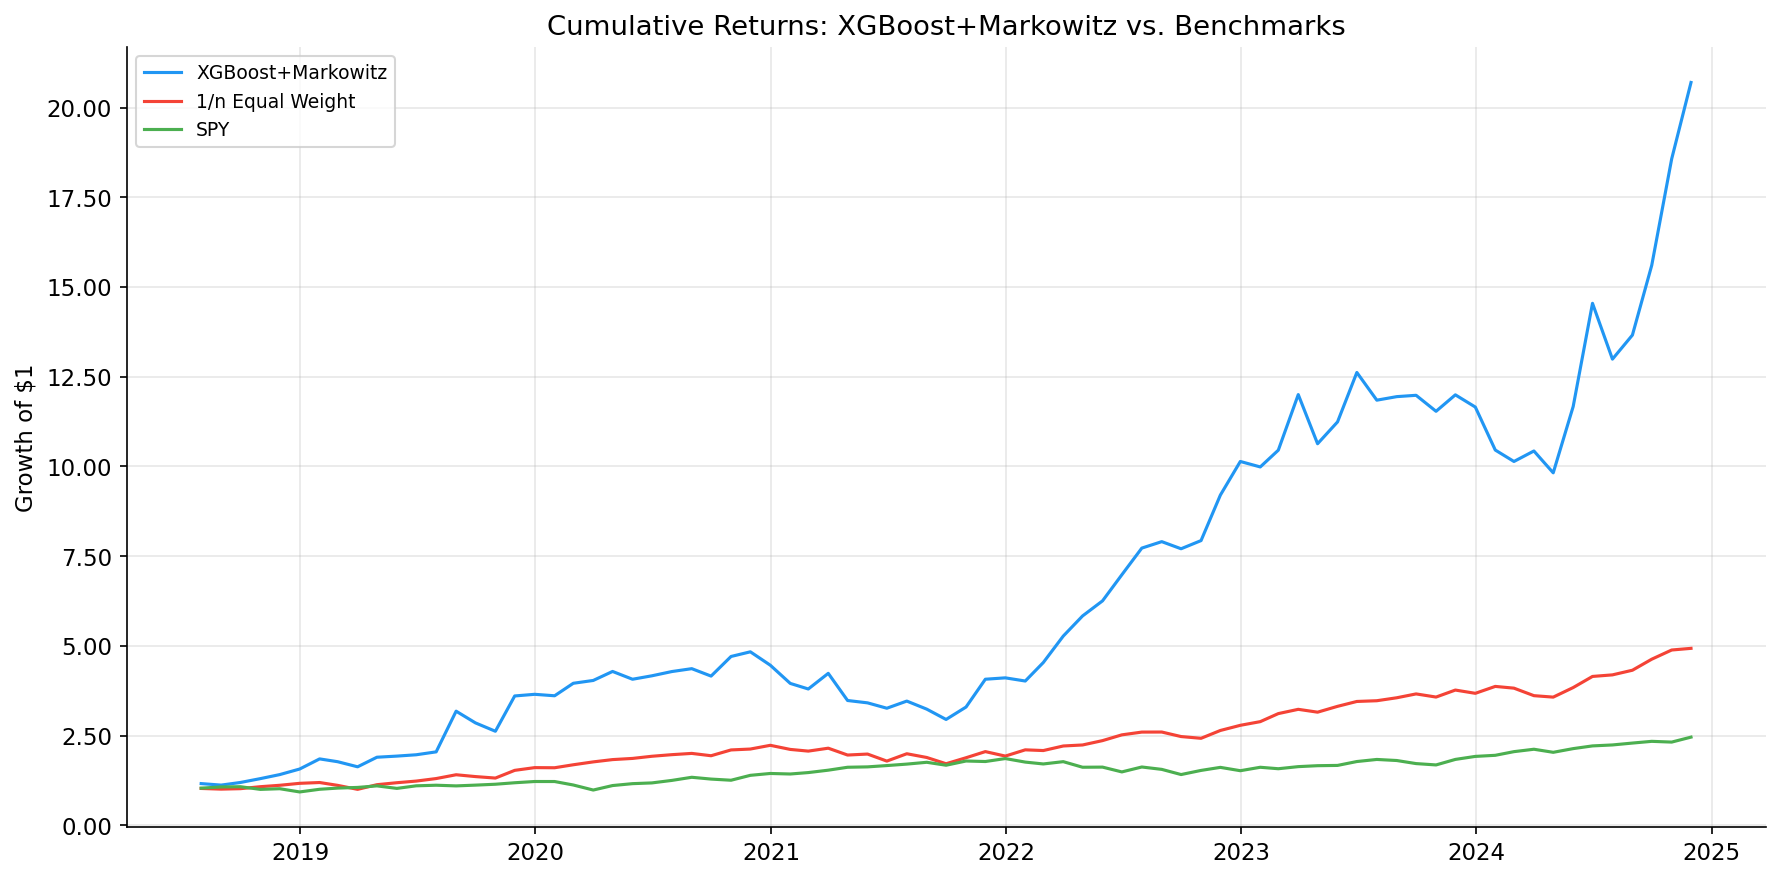

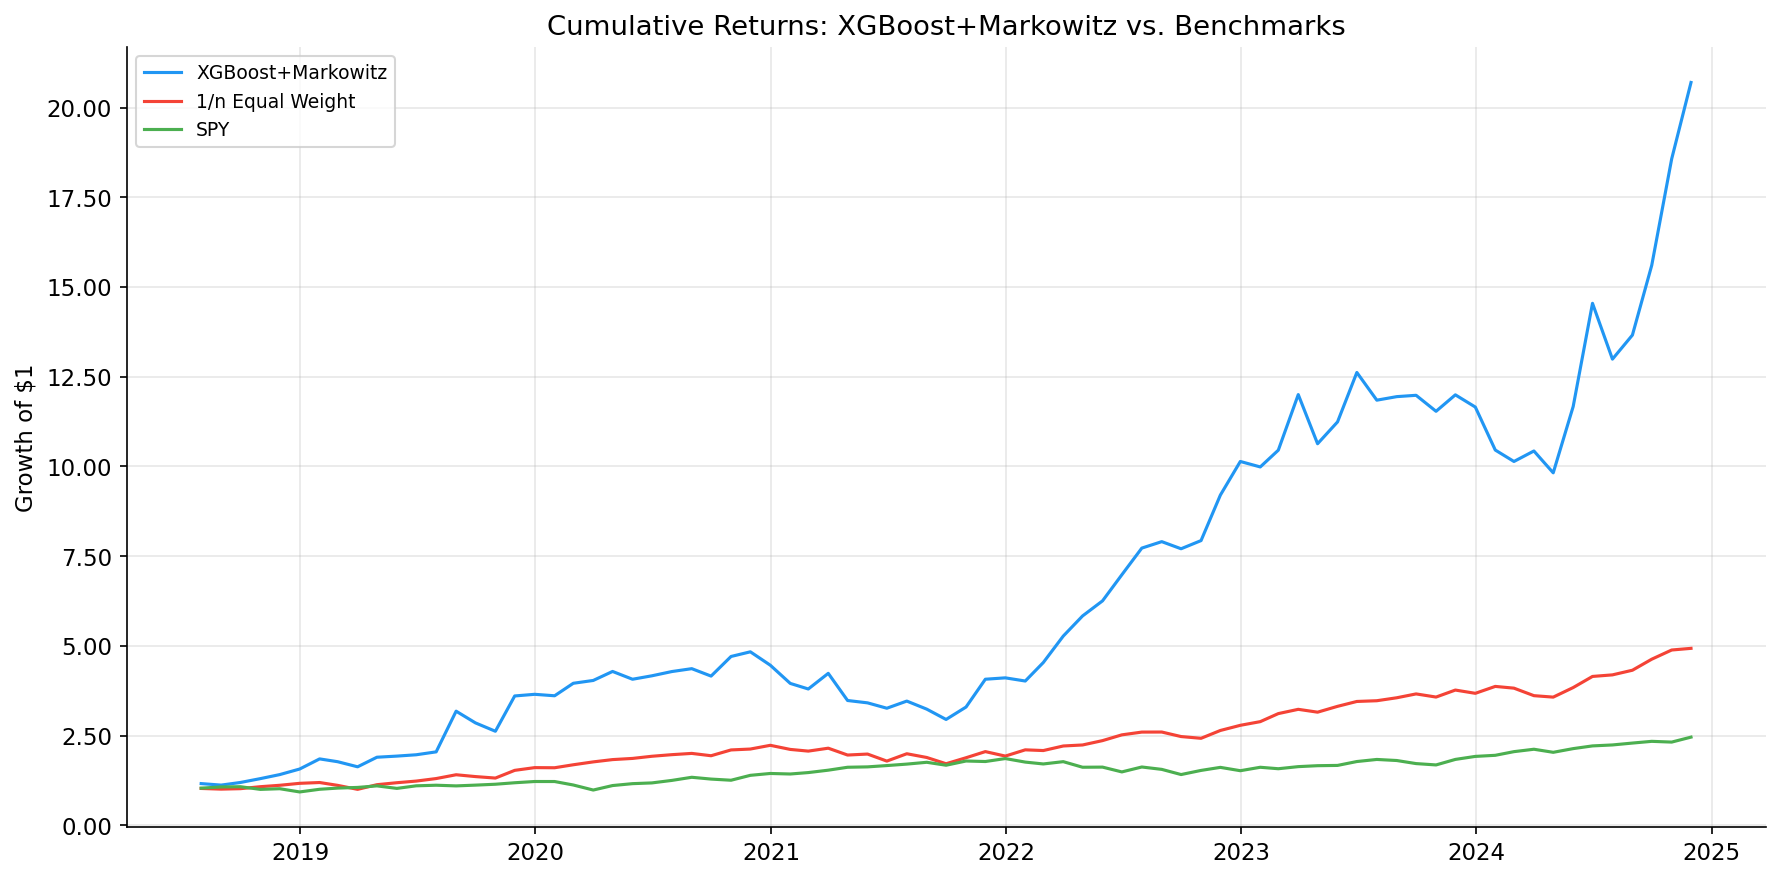

In [104]:
plot_cumulative_returns(
    returns_df,
    title='Cumulative Returns: XGBoost+Markowitz vs. Benchmarks',
)

### Drawdown

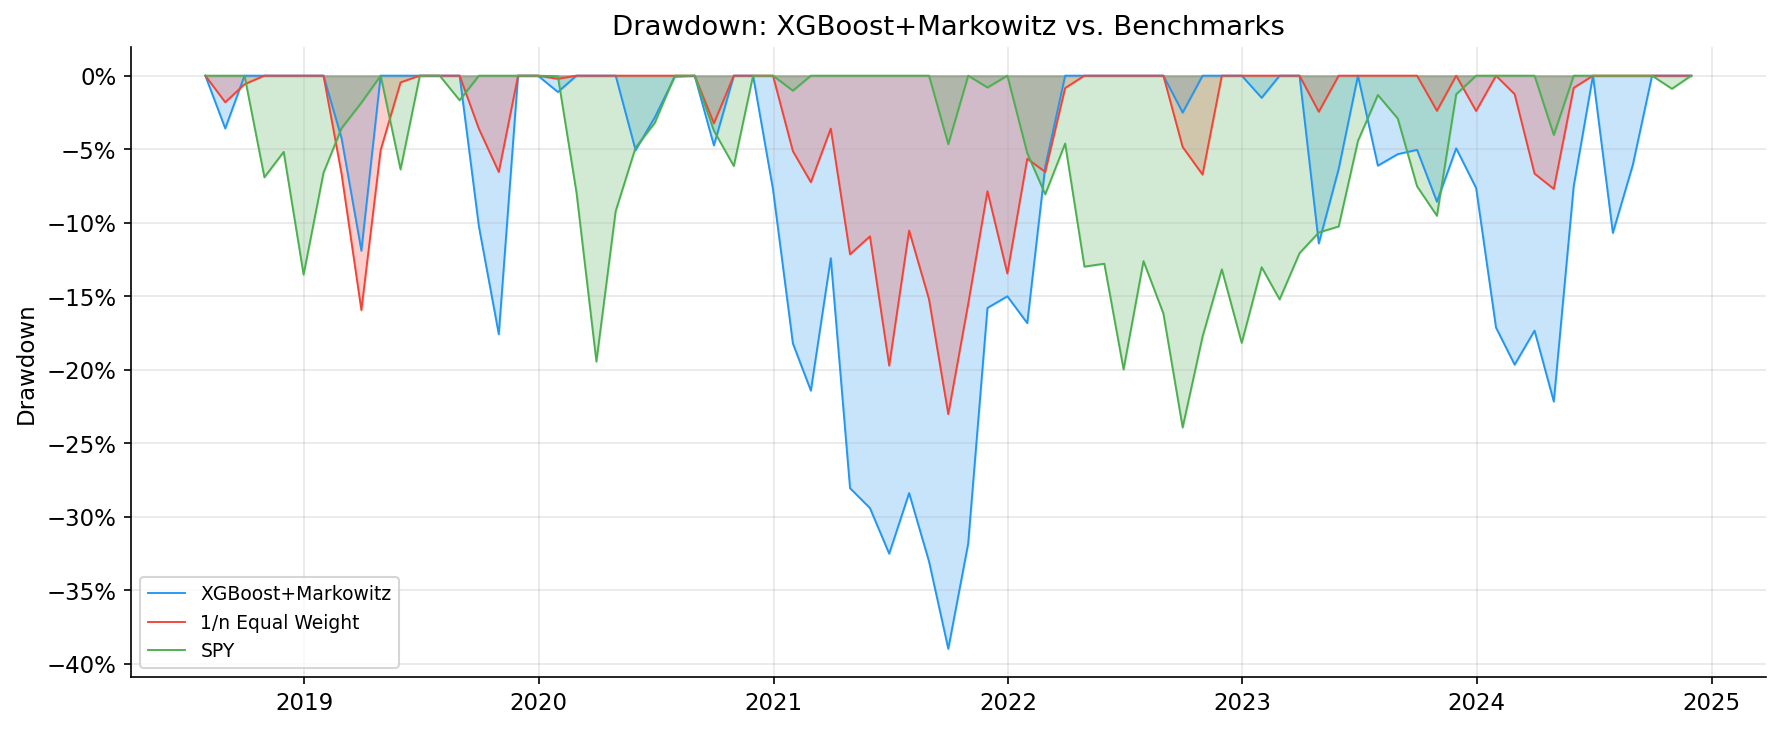

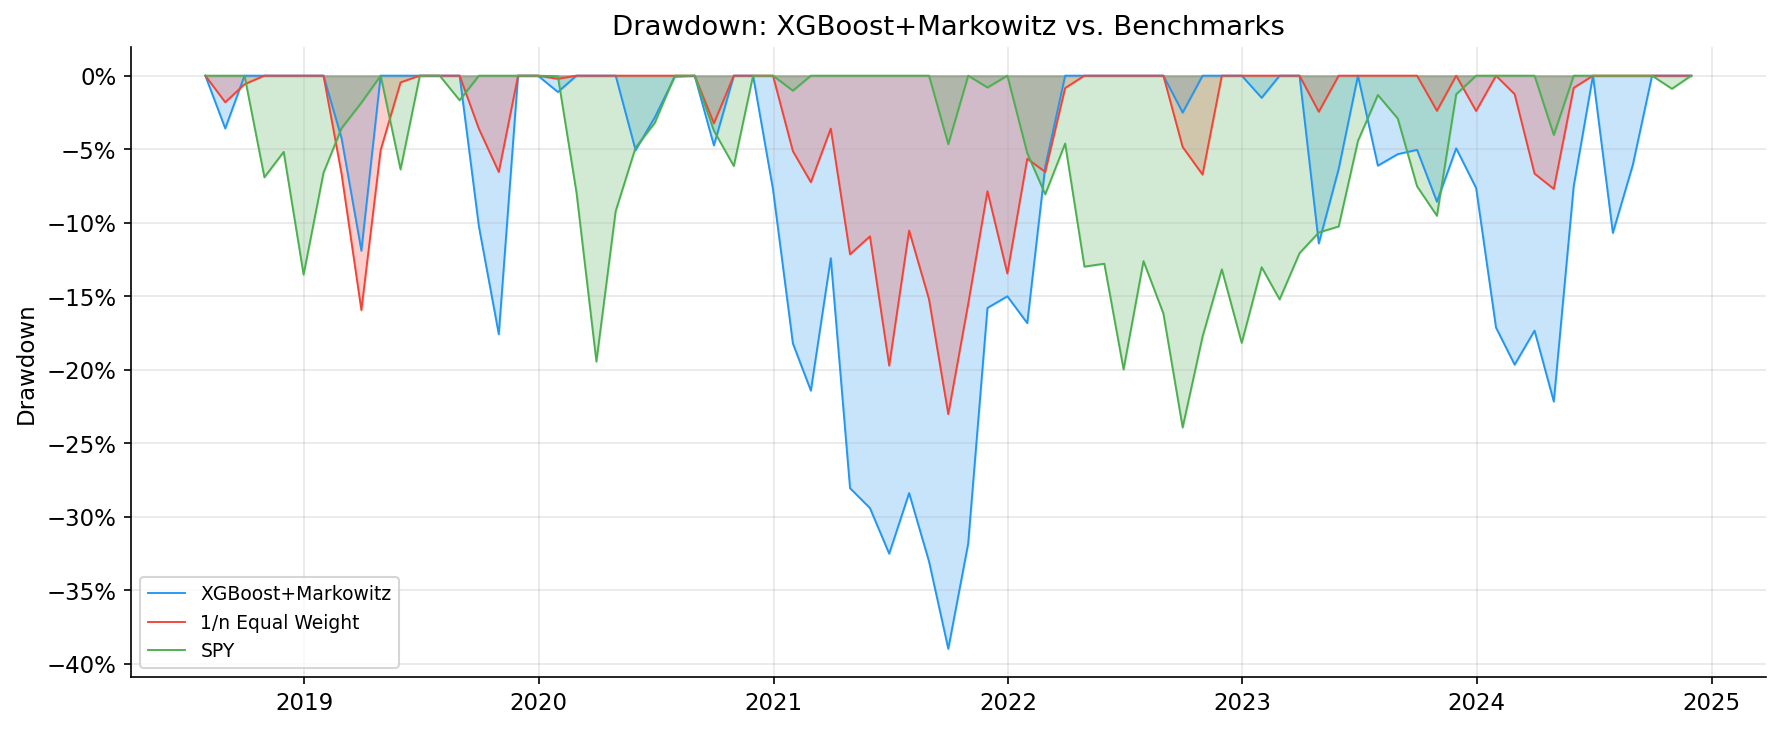

In [105]:
plot_drawdown(
    returns_df,
    title='Drawdown: XGBoost+Markowitz vs. Benchmarks',
)

### Rolling Sharpe Ratio

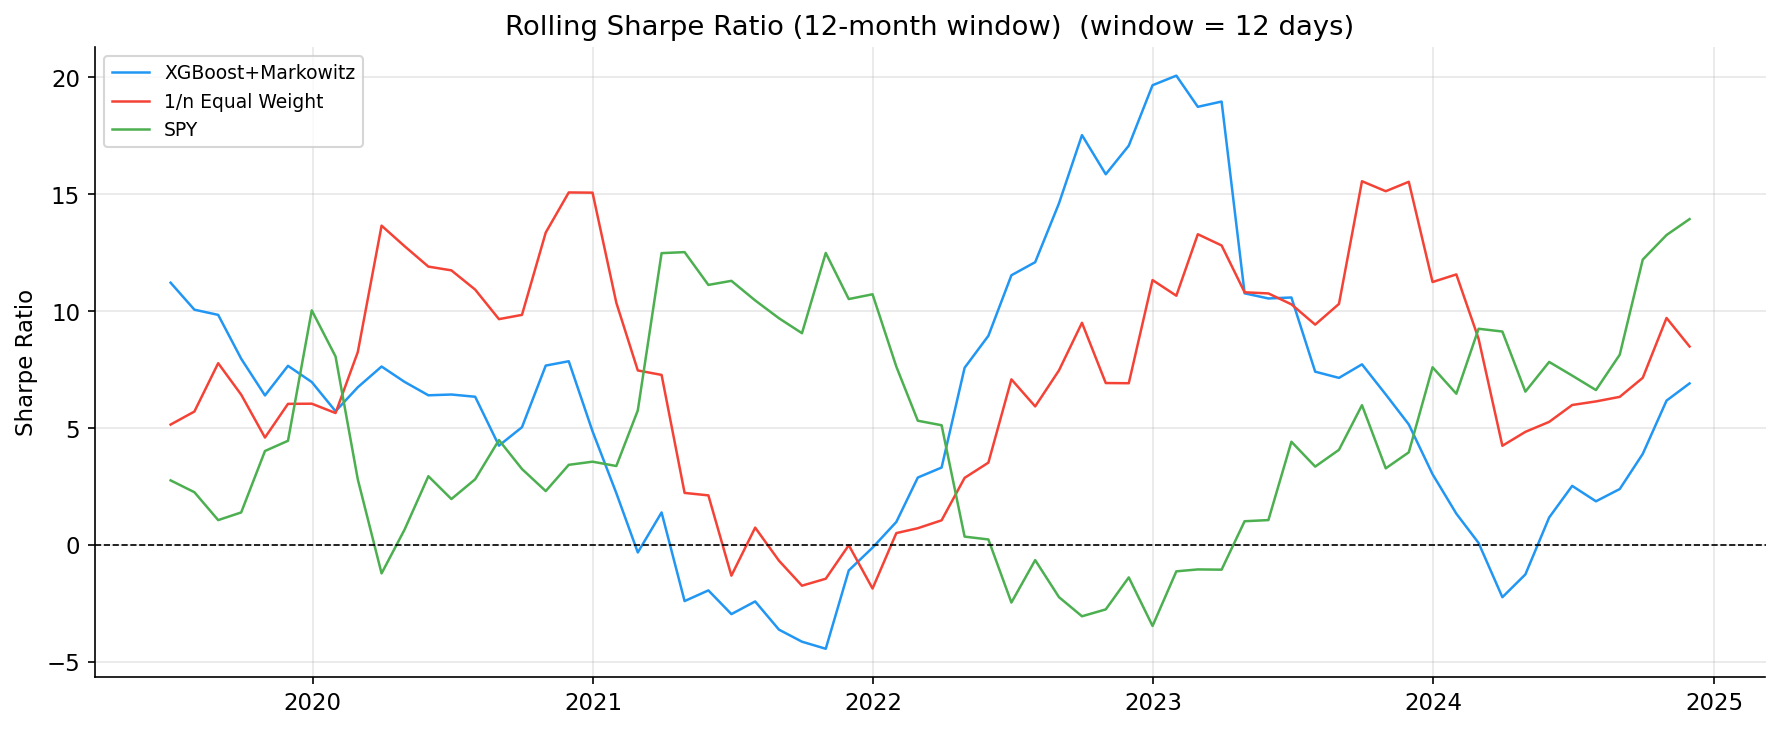

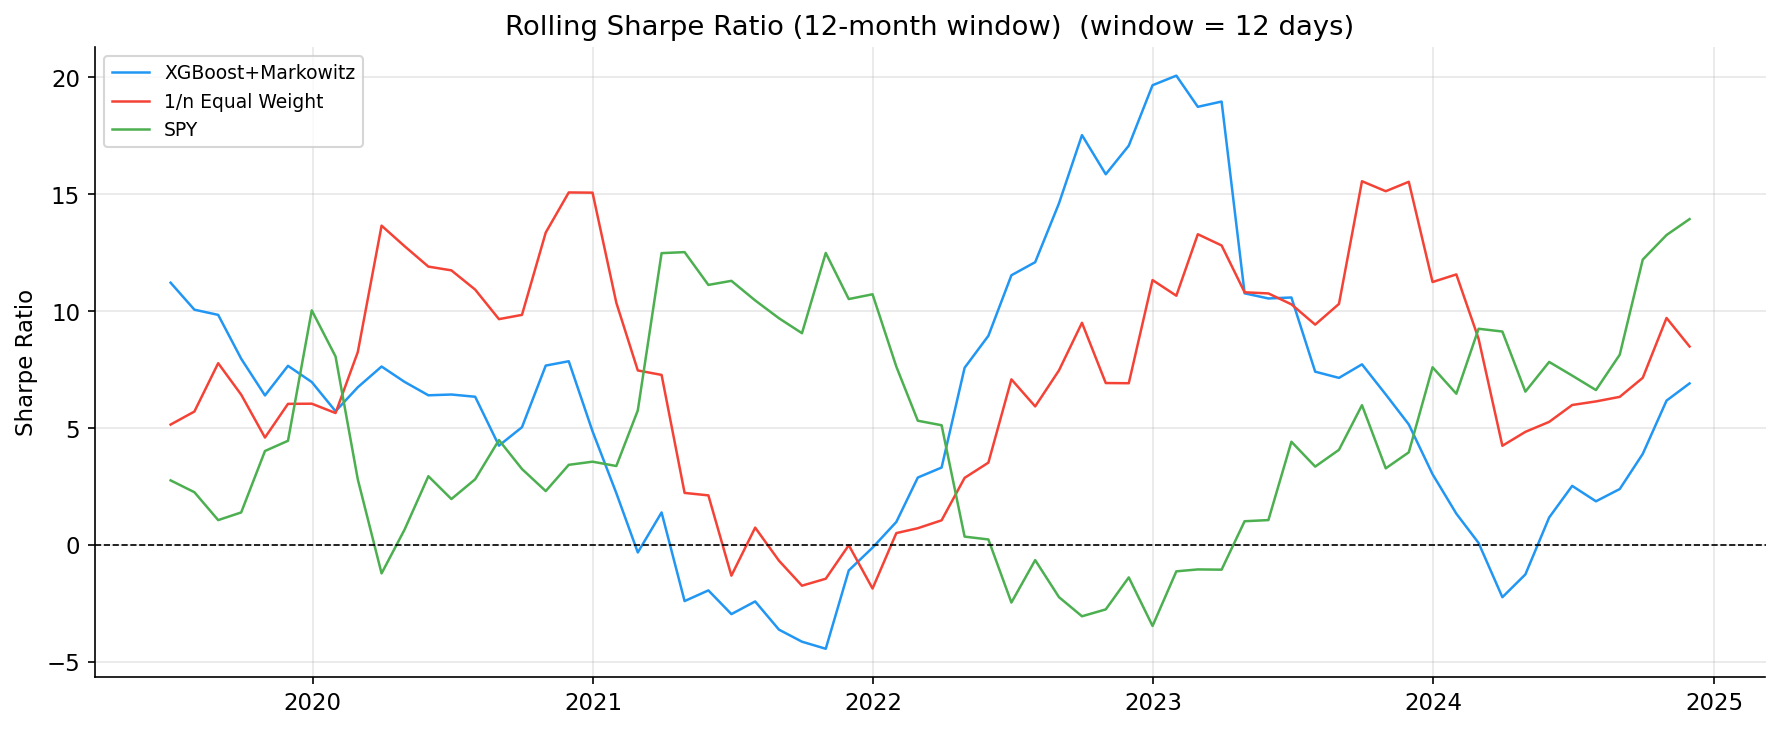

In [106]:
plot_rolling_sharpe(
    returns_df,
    window=12,
    title='Rolling Sharpe Ratio (12-month window)',
)

### Rolling Volatility

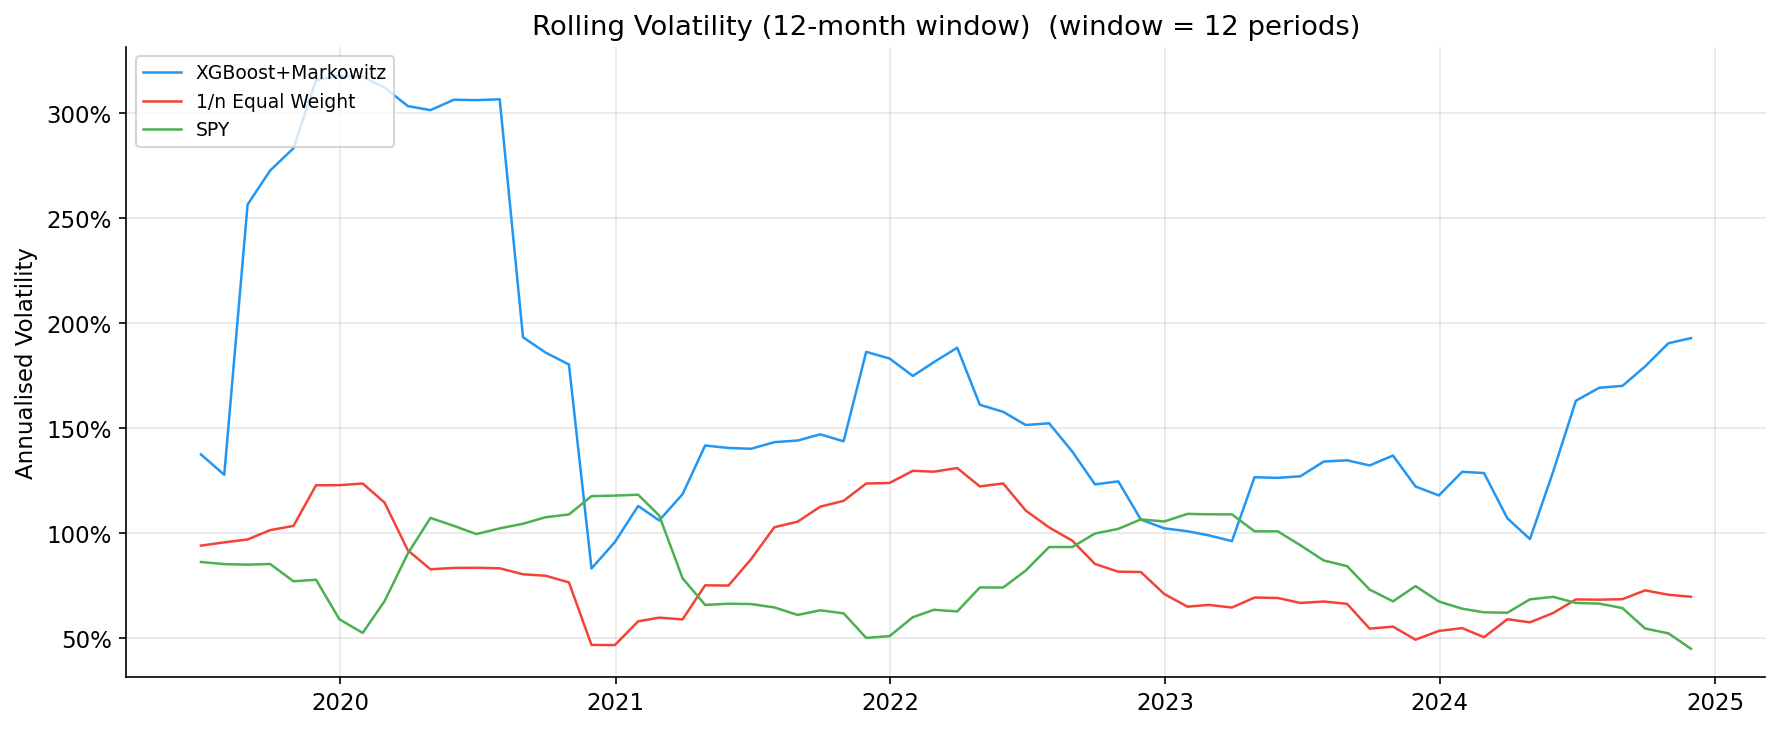

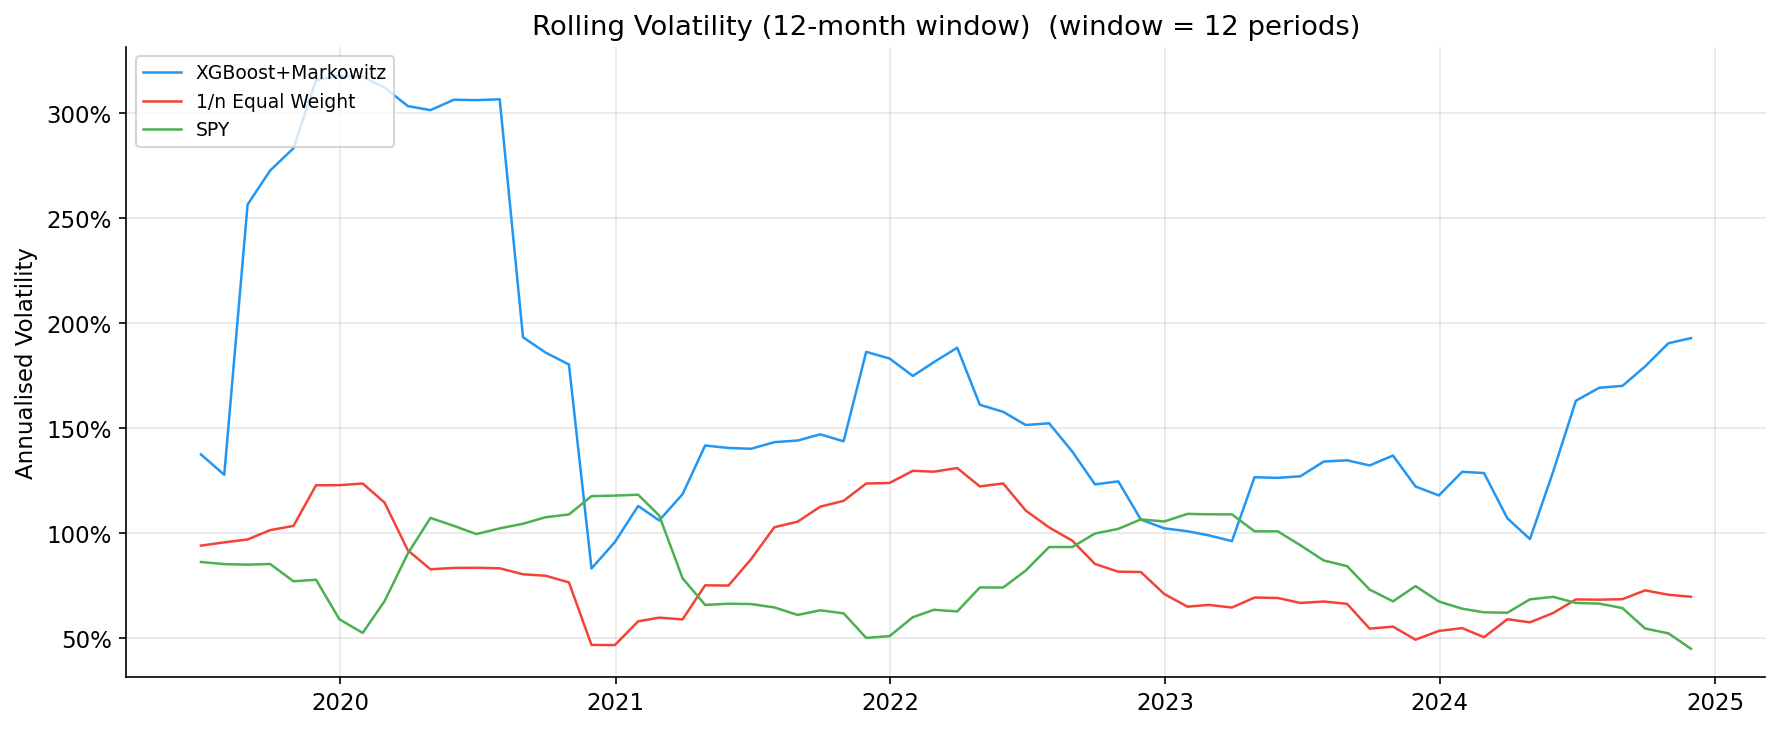

In [107]:
plot_rolling_volatility(
    returns_df,
    window=12,
    title='Rolling Volatility (12-month window)',
)

### Sharpe Ratio Comparison

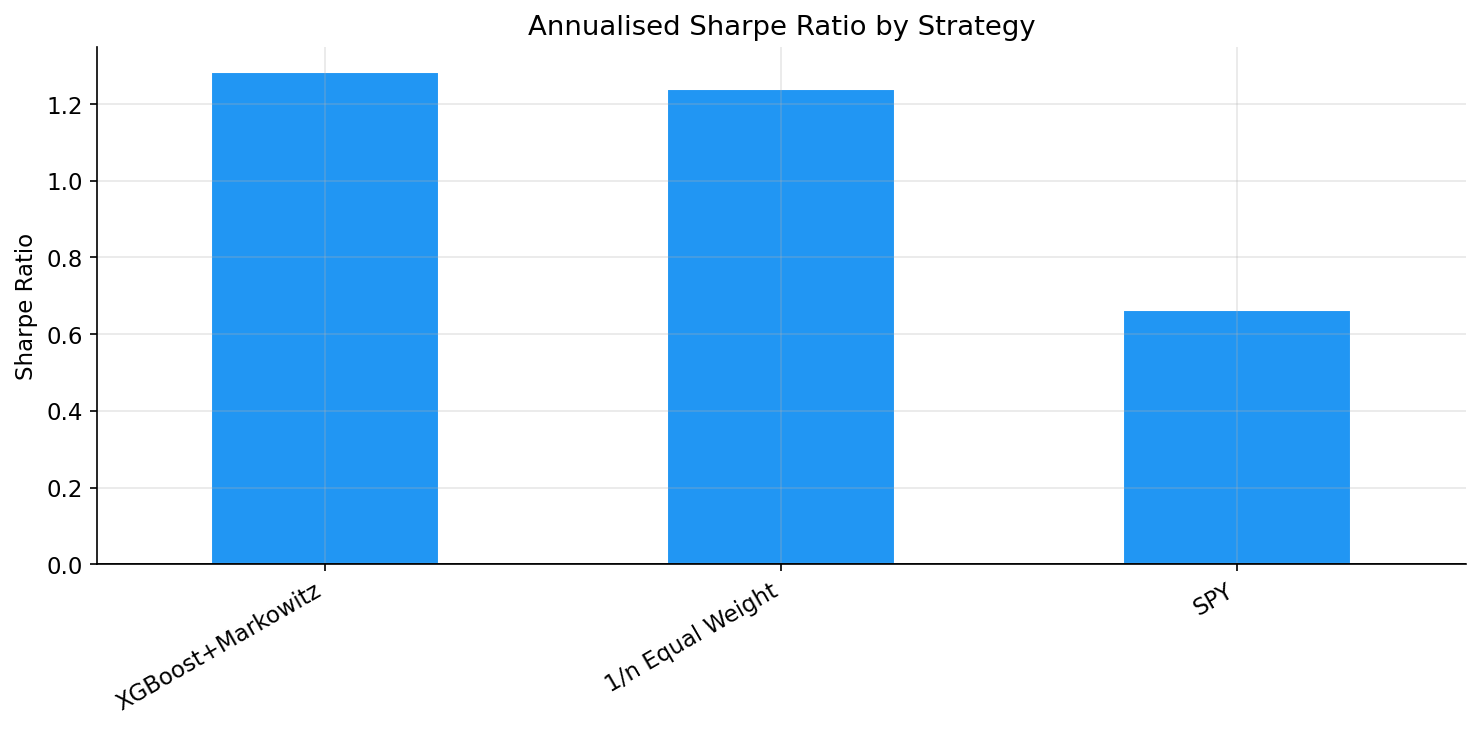

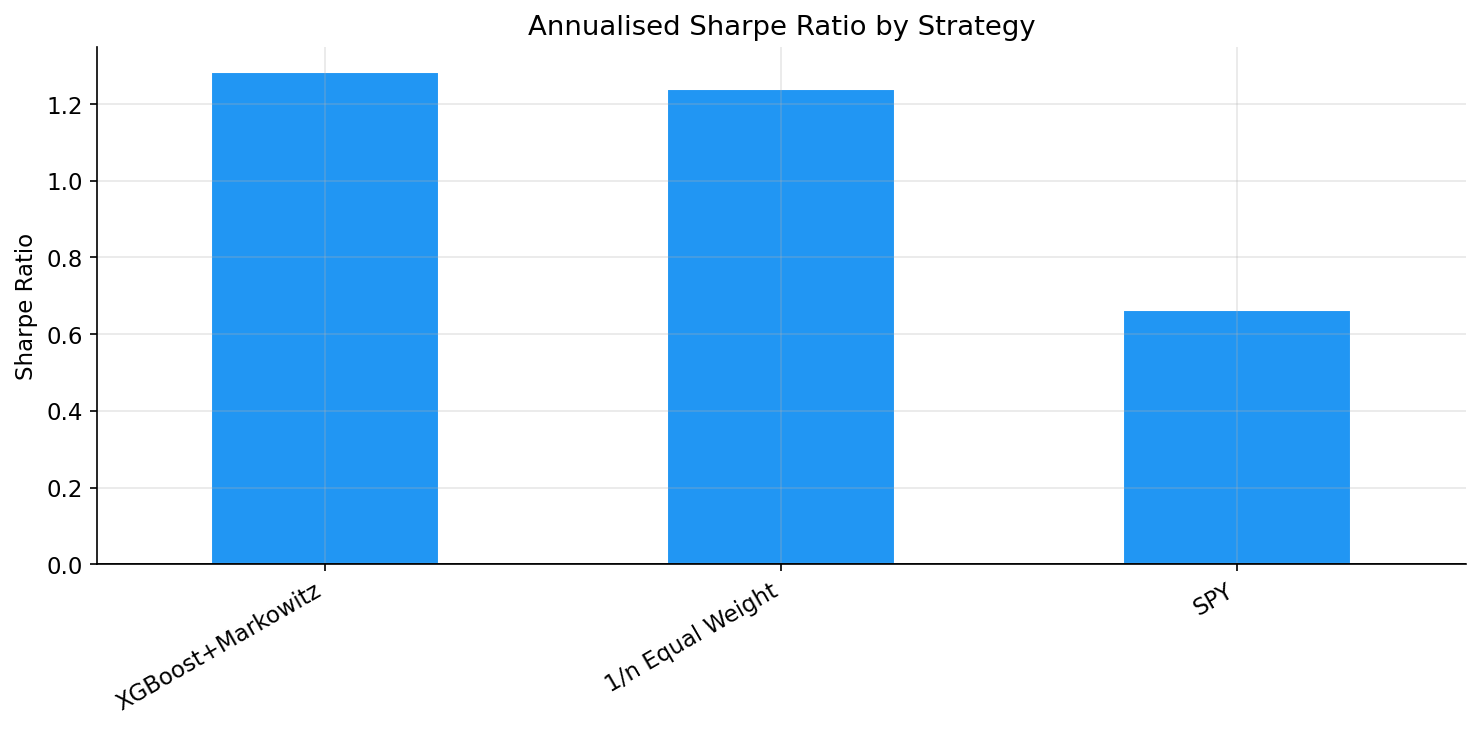

In [108]:
monthly_rf = RISK_FREE_RATE / 12
sharpe_series = pd.Series(
    {
        col: (returns_df[col].mean() - monthly_rf) / returns_df[col].std() * np.sqrt(12)
        for col in returns_df.columns
    },
    name='Annualised Sharpe',
)
plot_sharpe_bar(sharpe_series, title='Annualised Sharpe Ratio by Strategy')

### Performance Summary

,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Max Drawdown (%)
XGBoost+Markowitz,55.135,39.807,1.285,-38.978
1/n Equal Weight,26.779,18.394,1.238,-23.022
SPY,15.634,17.582,0.662,-23.927


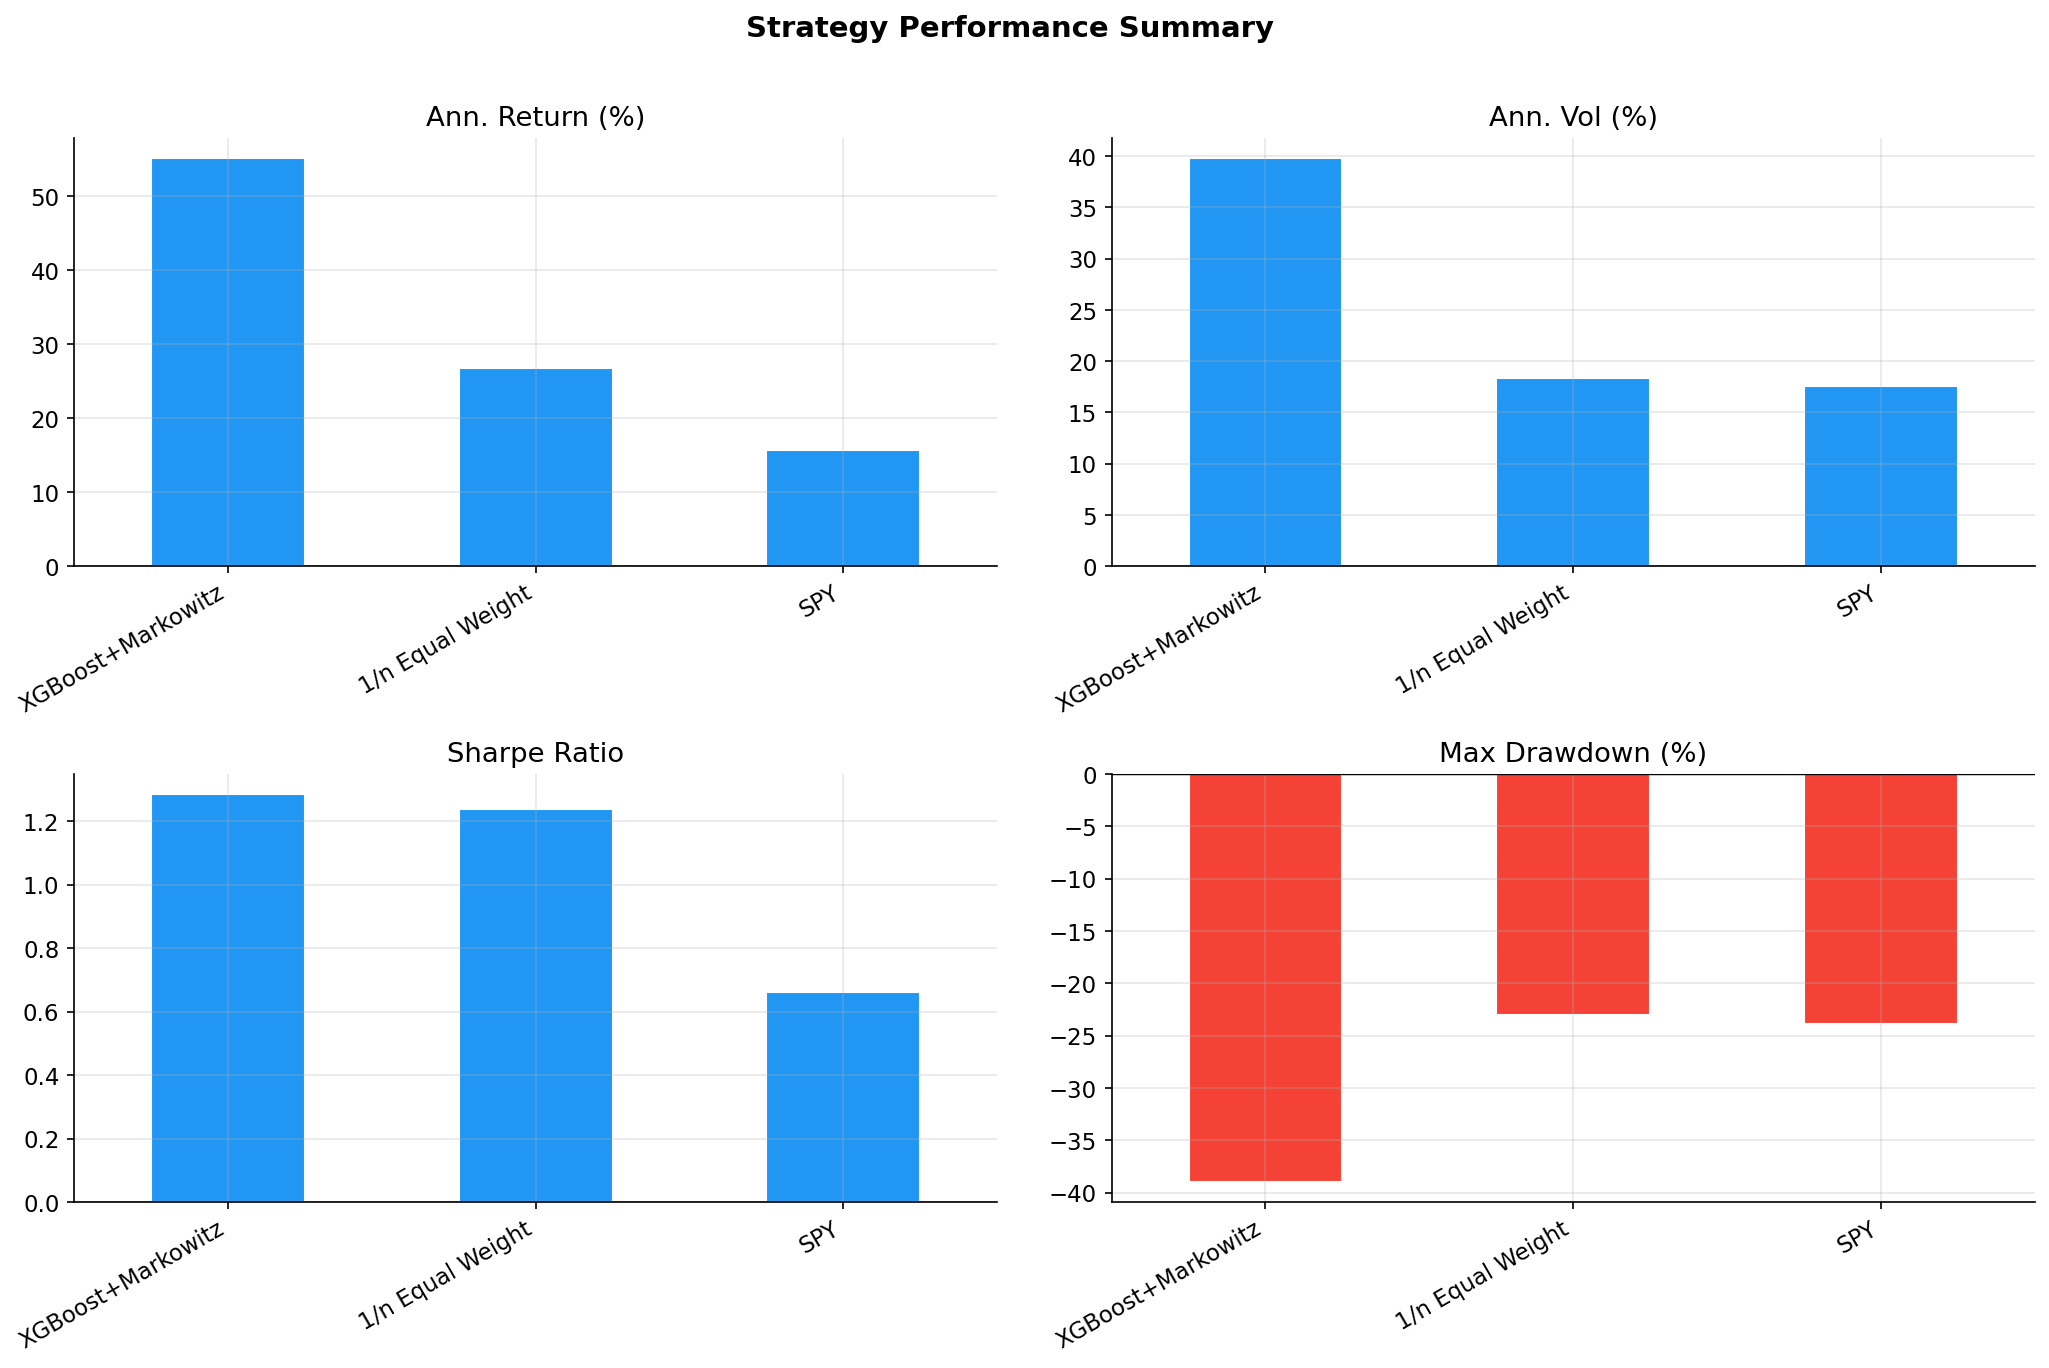

In [109]:
monthly_rf = RISK_FREE_RATE / 12
stats = {}
for col in returns_df.columns:
    r = returns_df[col]
    cum = (1 + r).cumprod()
    dd  = ((cum / cum.cummax()) - 1).min()
    stats[col] = {
        'Ann. Return (%)':  r.mean() * 12 * 100,
        'Ann. Vol (%)':     r.std()  * np.sqrt(12) * 100,
        'Sharpe Ratio':     (r.mean() - monthly_rf) / r.std() * np.sqrt(12),
        'Max Drawdown (%)': dd * 100,
    }

stats_df = pd.DataFrame(stats).T
plot_performance_summary(stats_df)
stats_df.round(3)

### Strategy Return Correlations

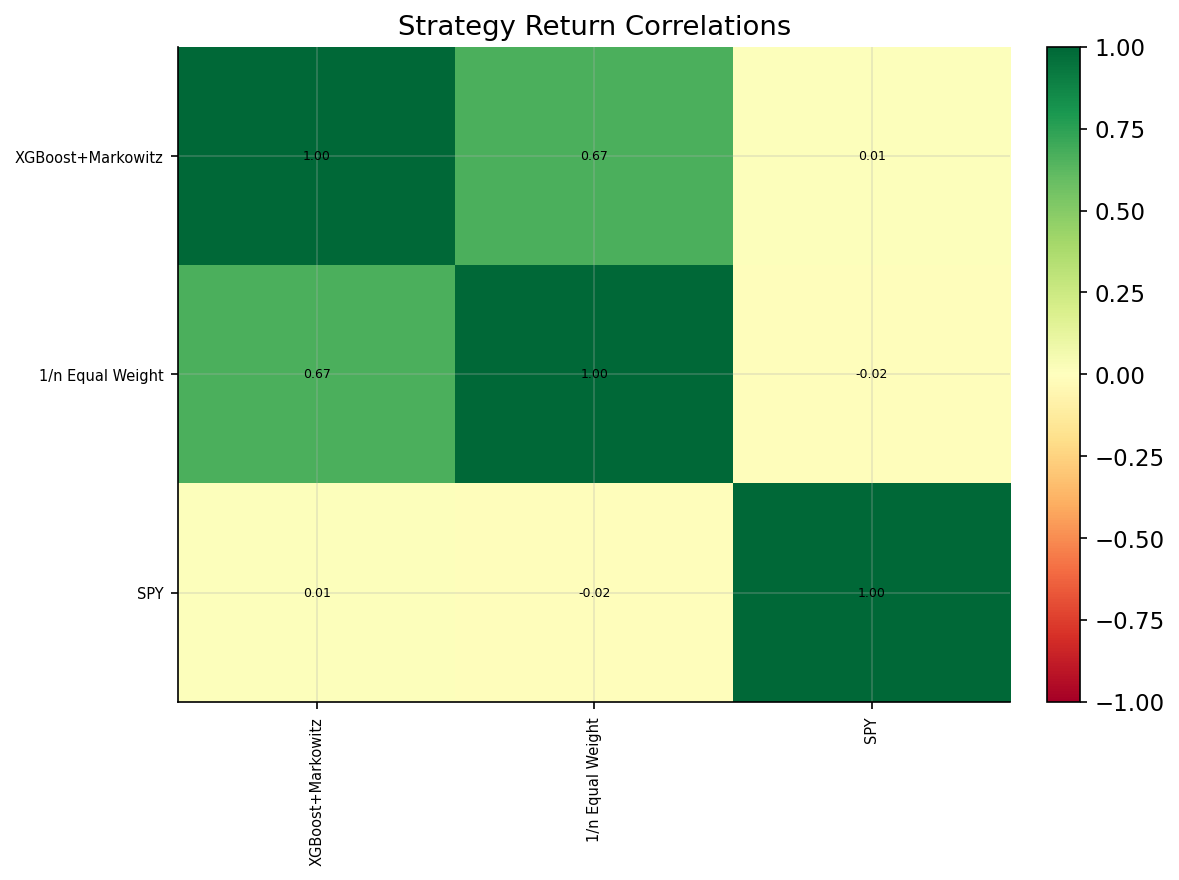

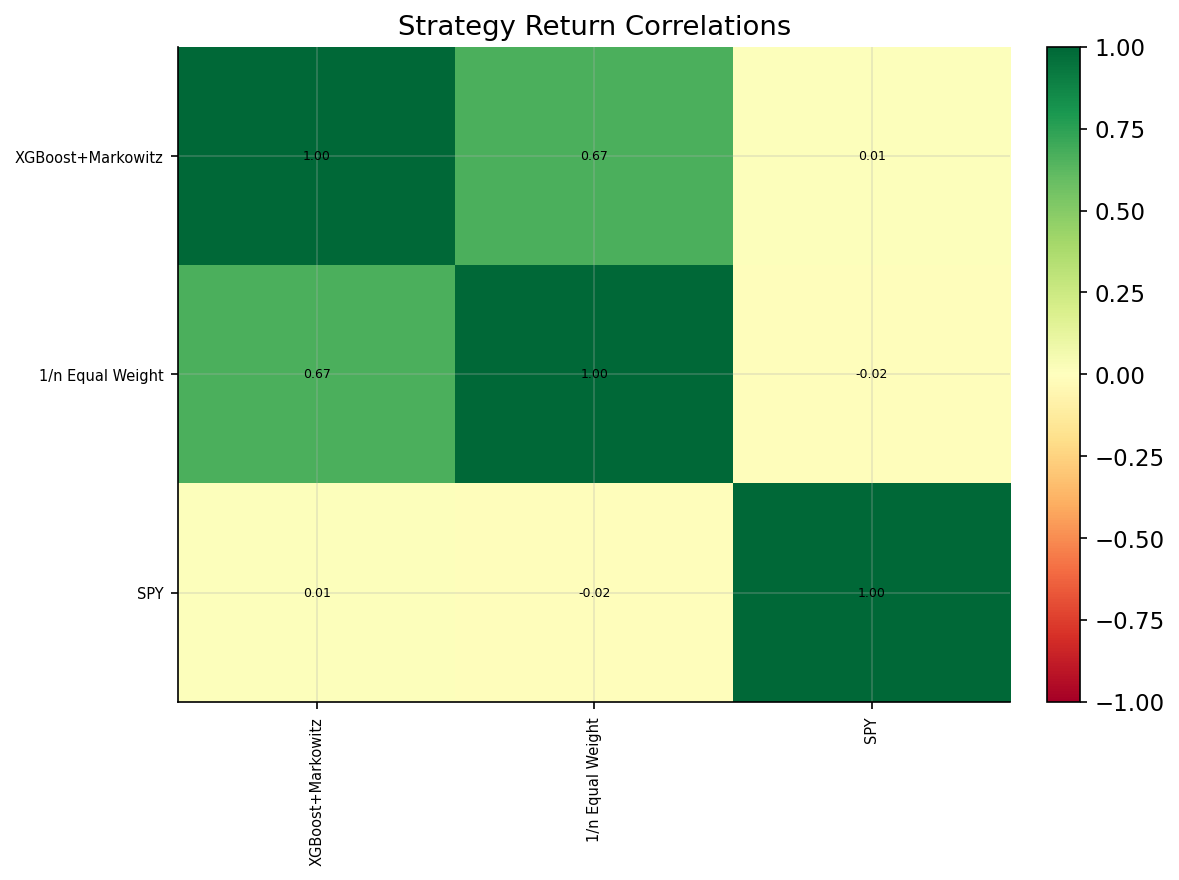

In [110]:
plot_correlation_heatmap(
    returns_df,
    title='Strategy Return Correlations',
)

### Asset Return Correlations

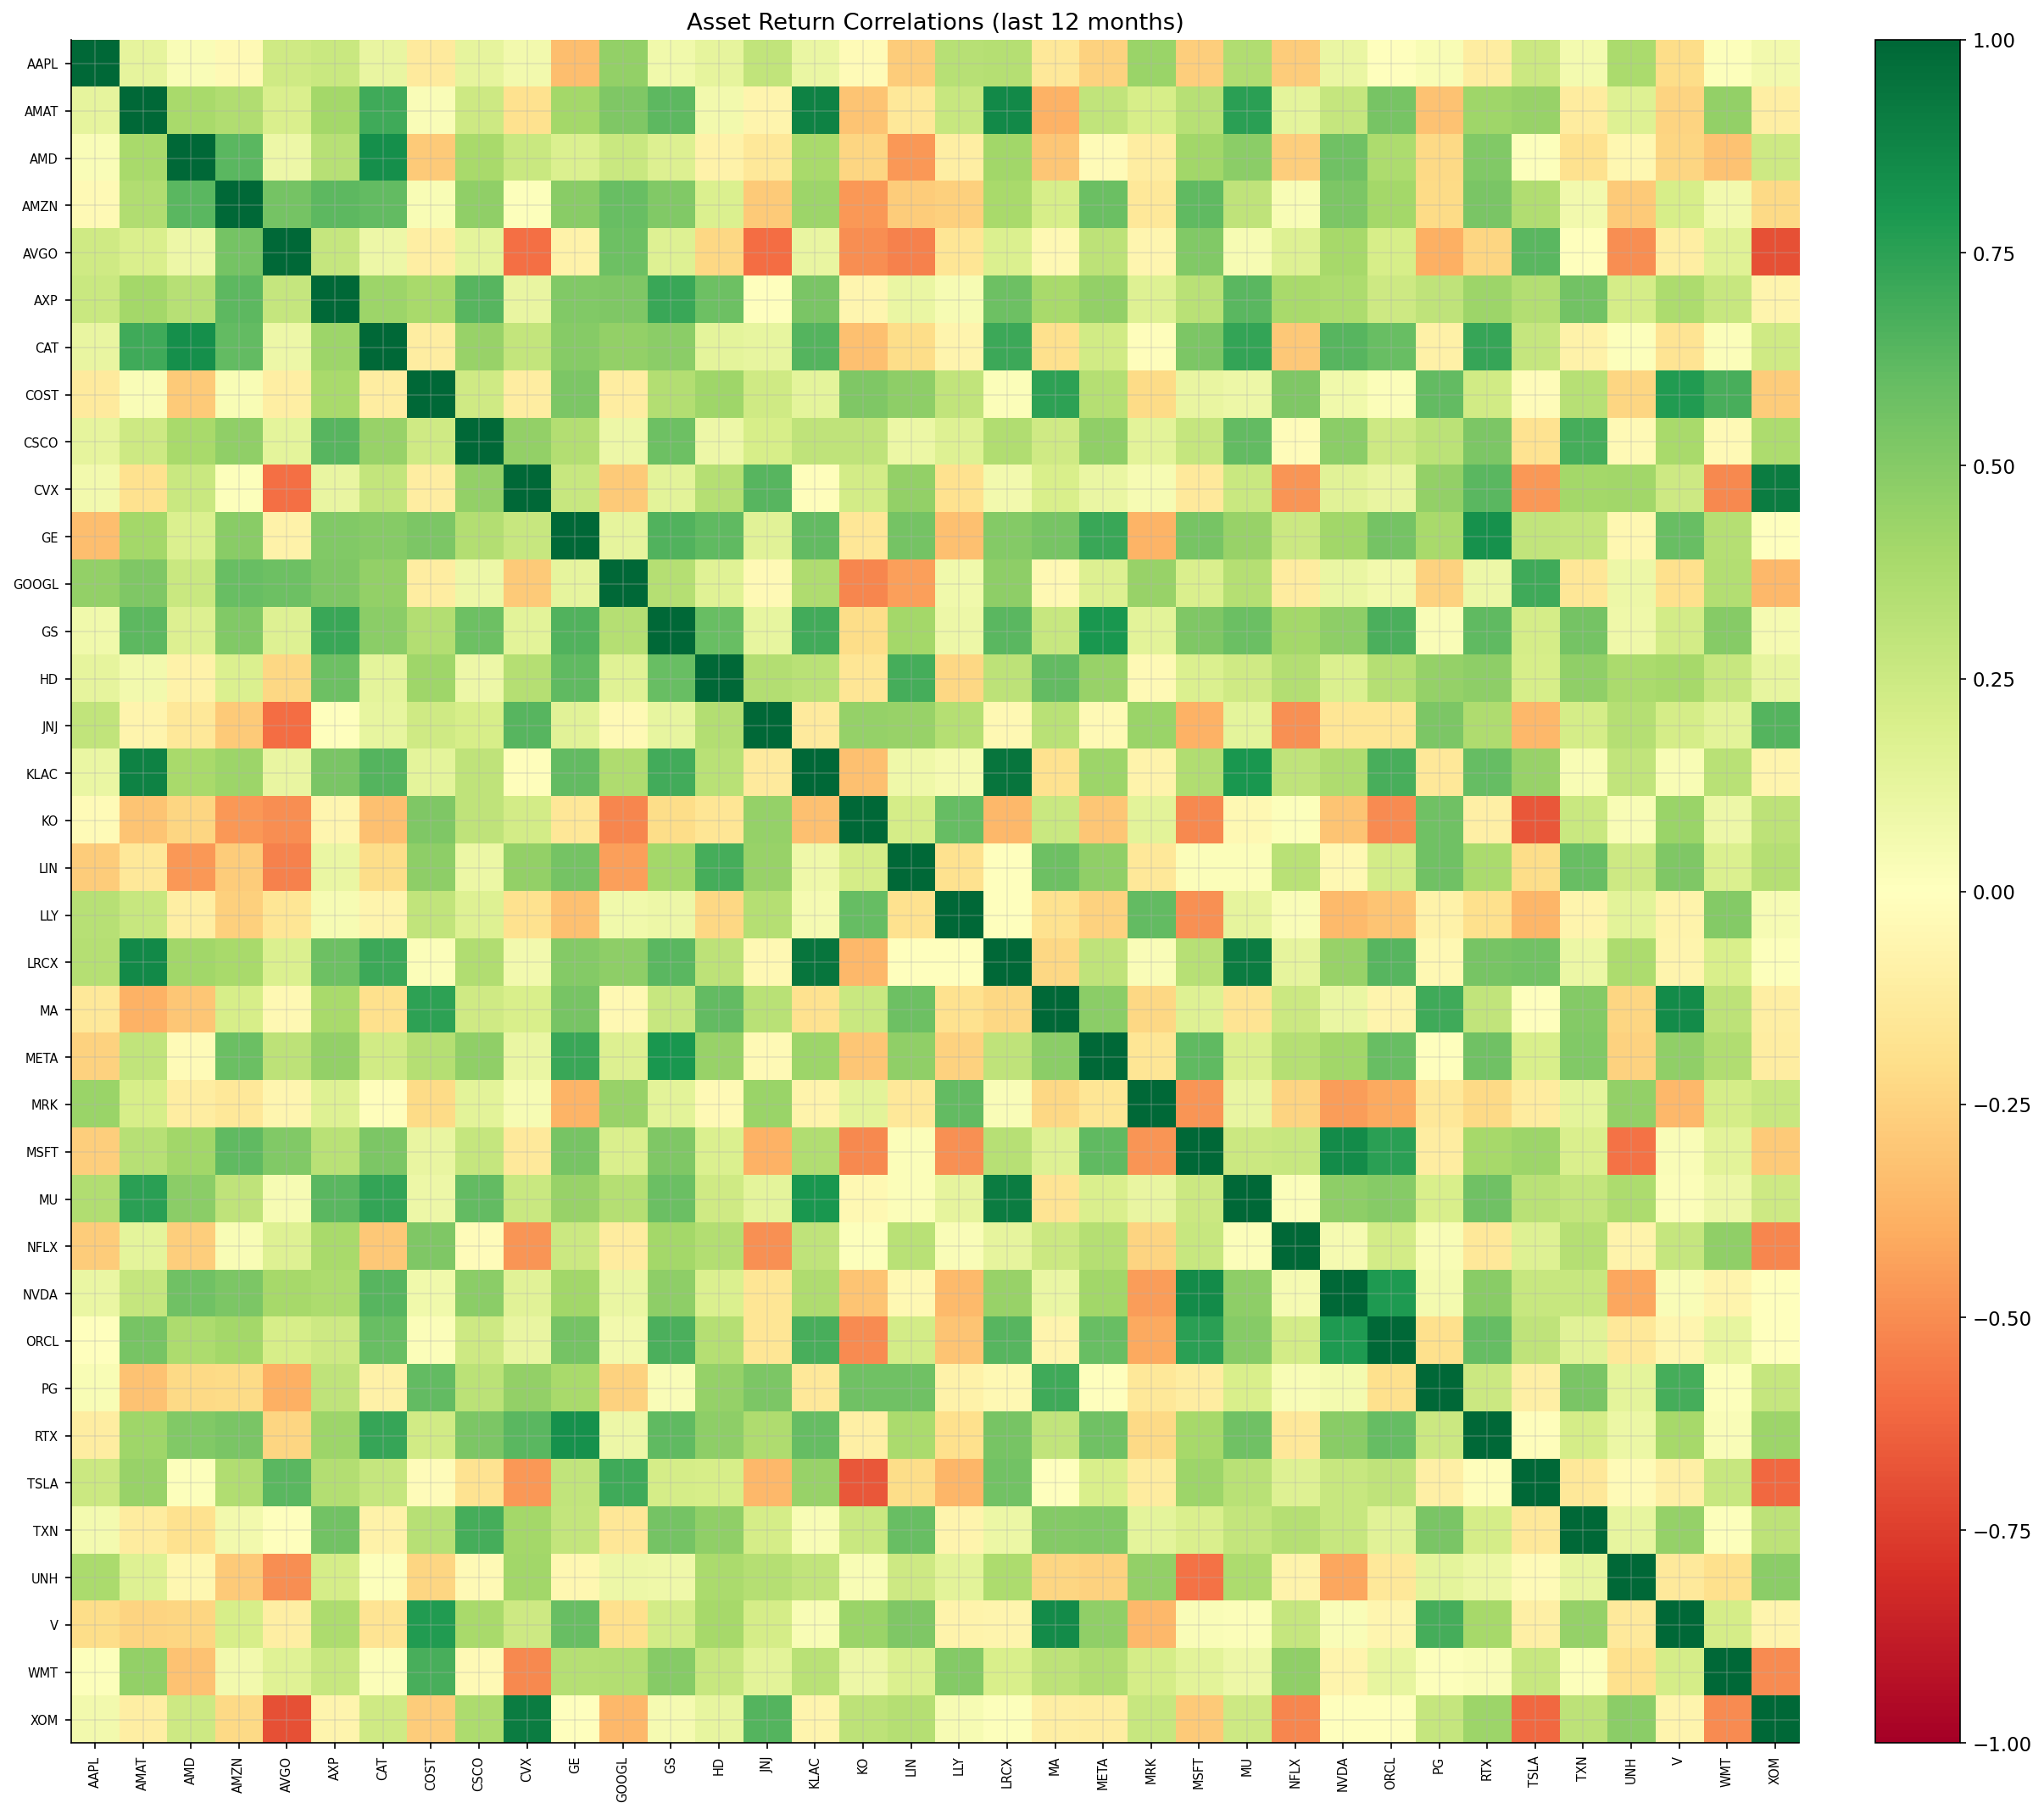

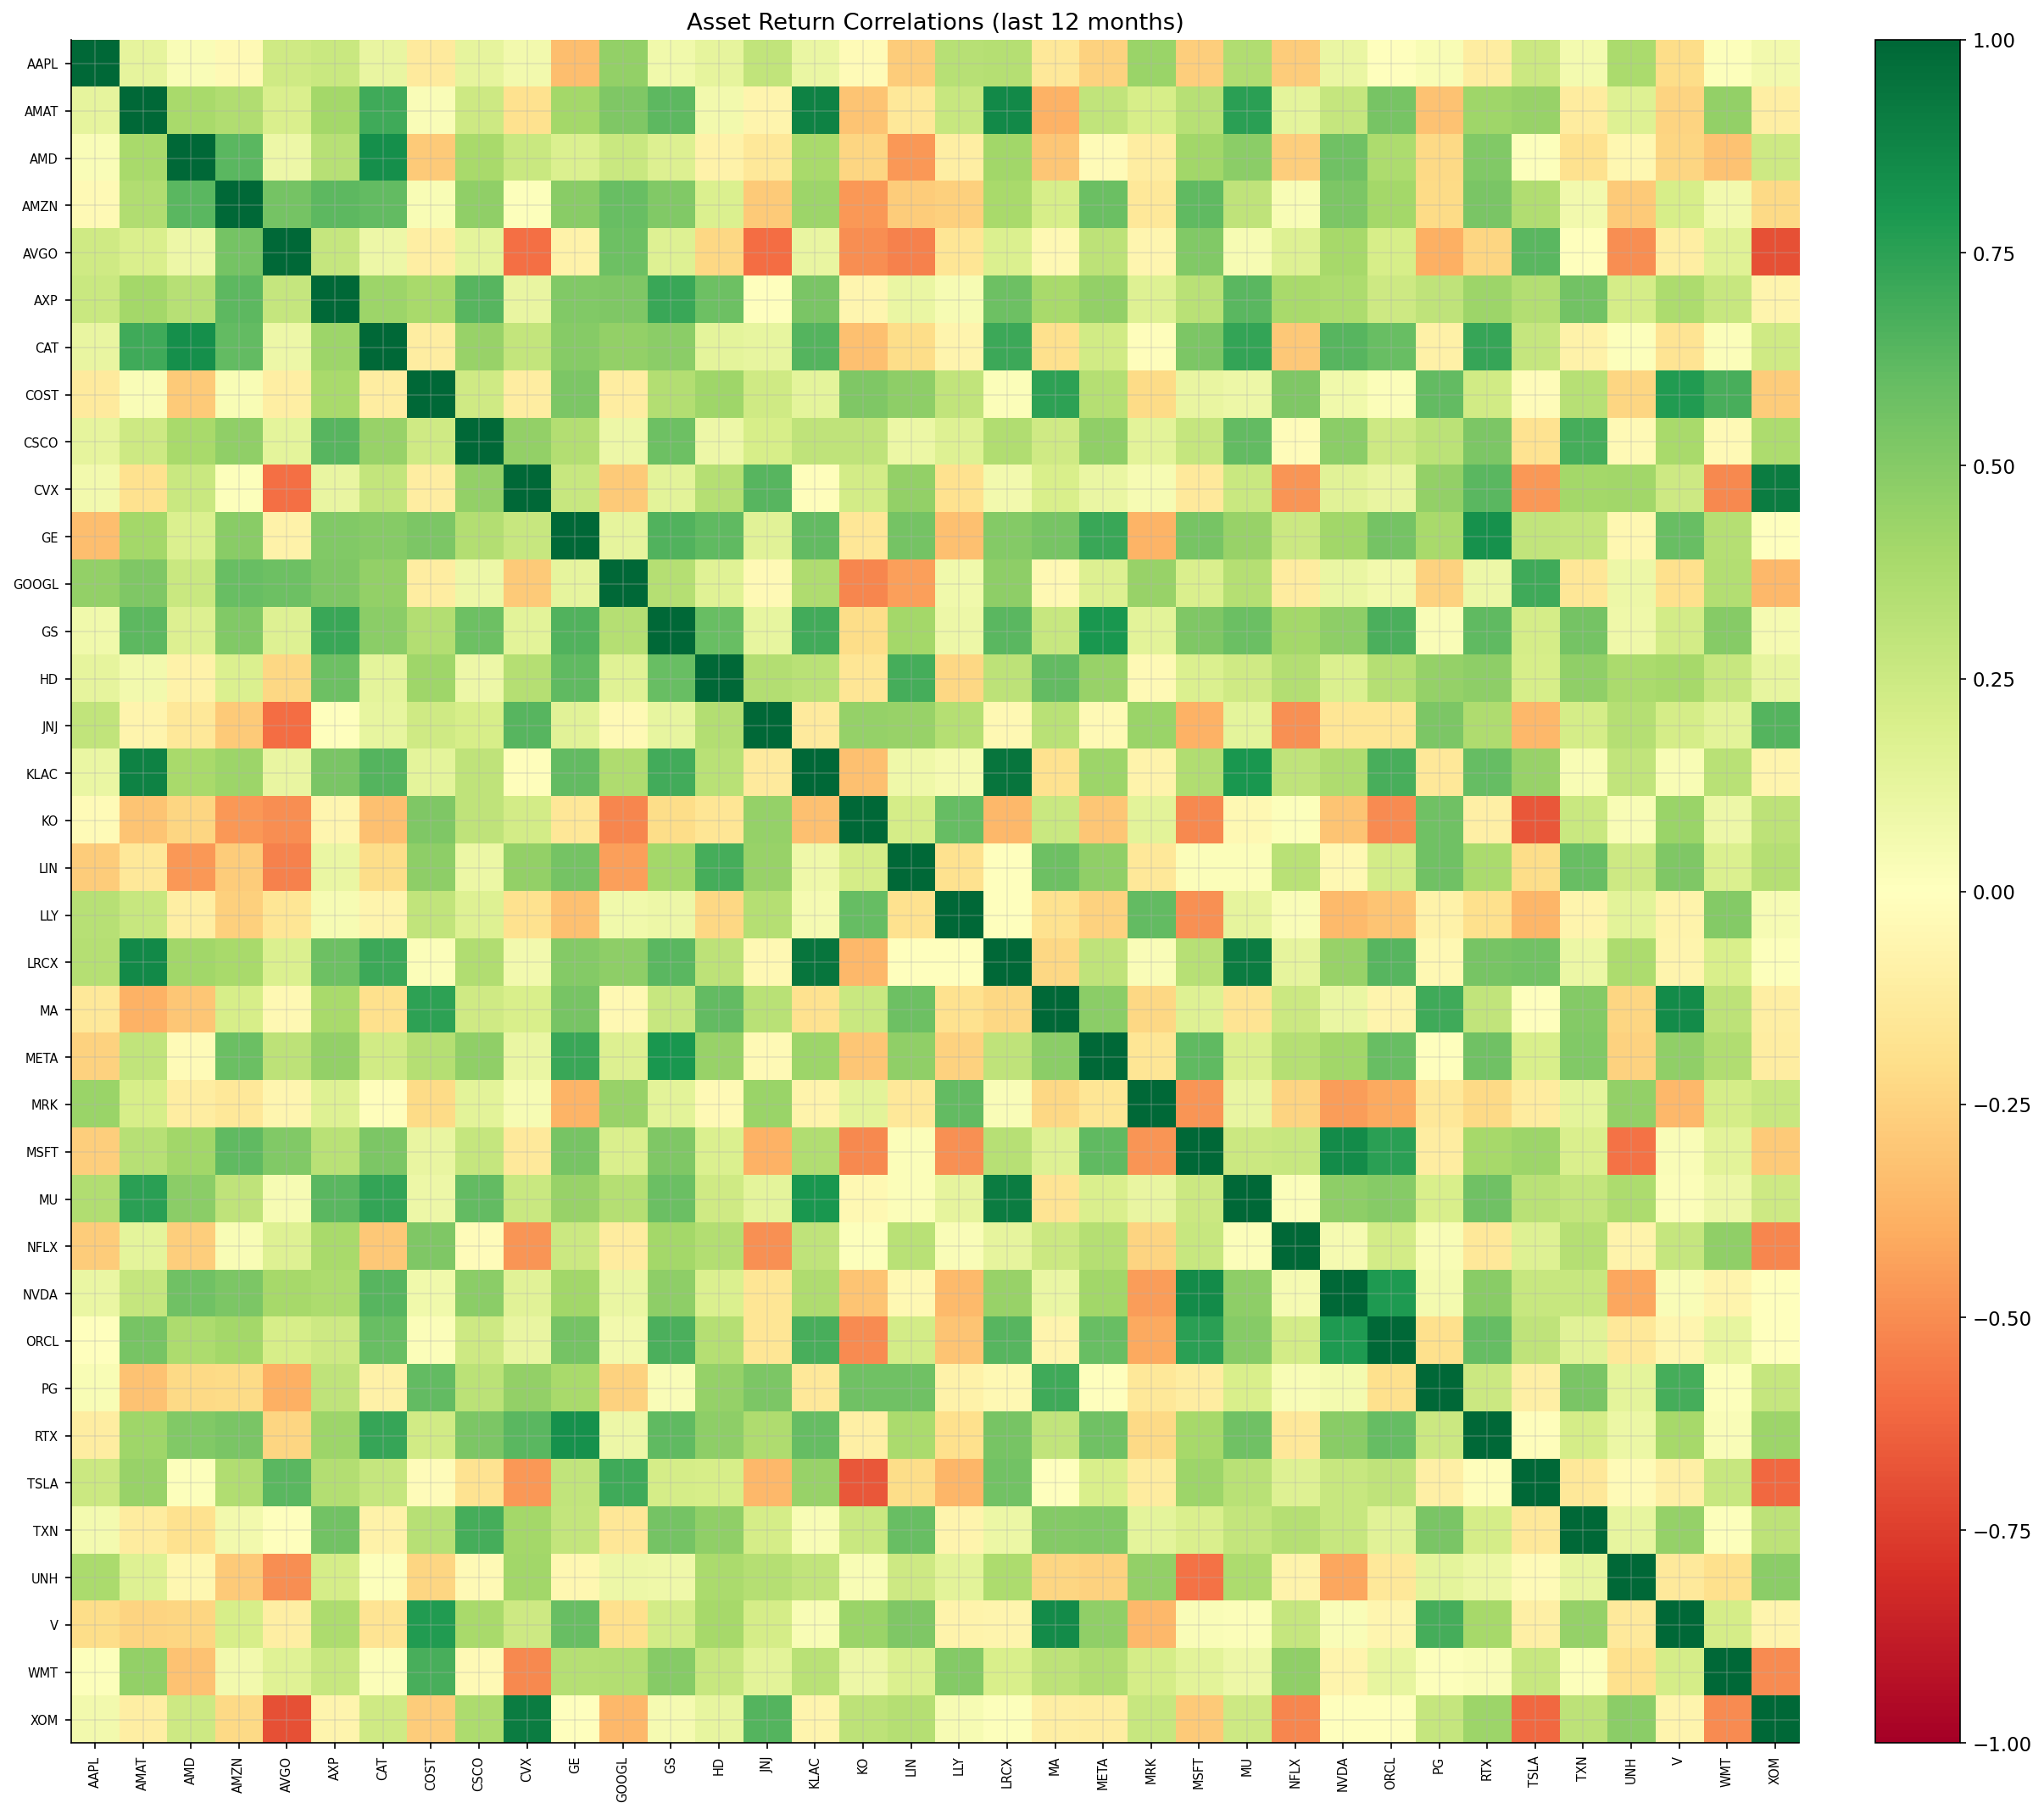

In [86]:
# Correlation across constituent assets over the last LOOKBACK_COV months.
recent_rets = monthly_returns.iloc[-LOOKBACK_COV:]
plot_correlation_heatmap(
    recent_rets.dropna(axis=1, how='any'),
    title=f'Asset Return Correlations (last {LOOKBACK_COV} months)',
)

### Portfolio Weights Heatmap

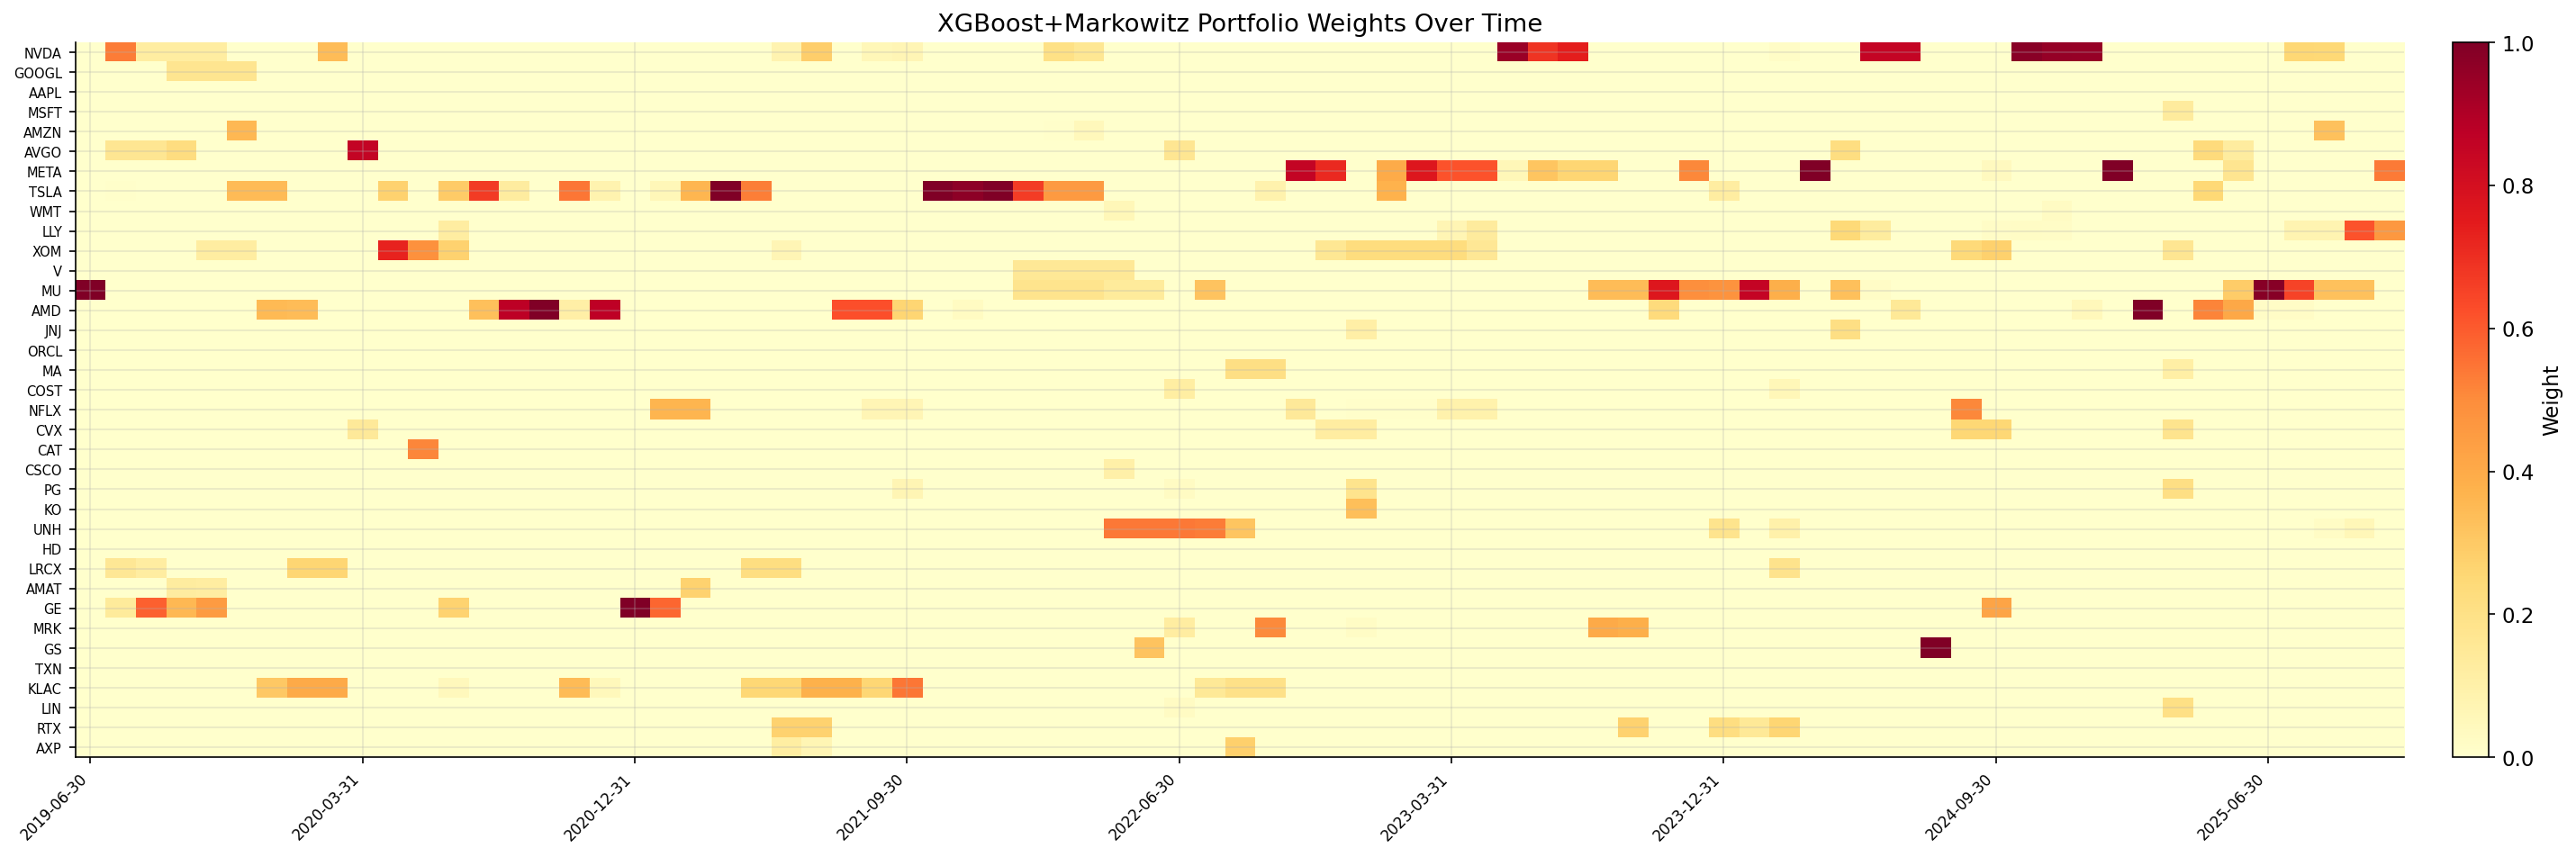

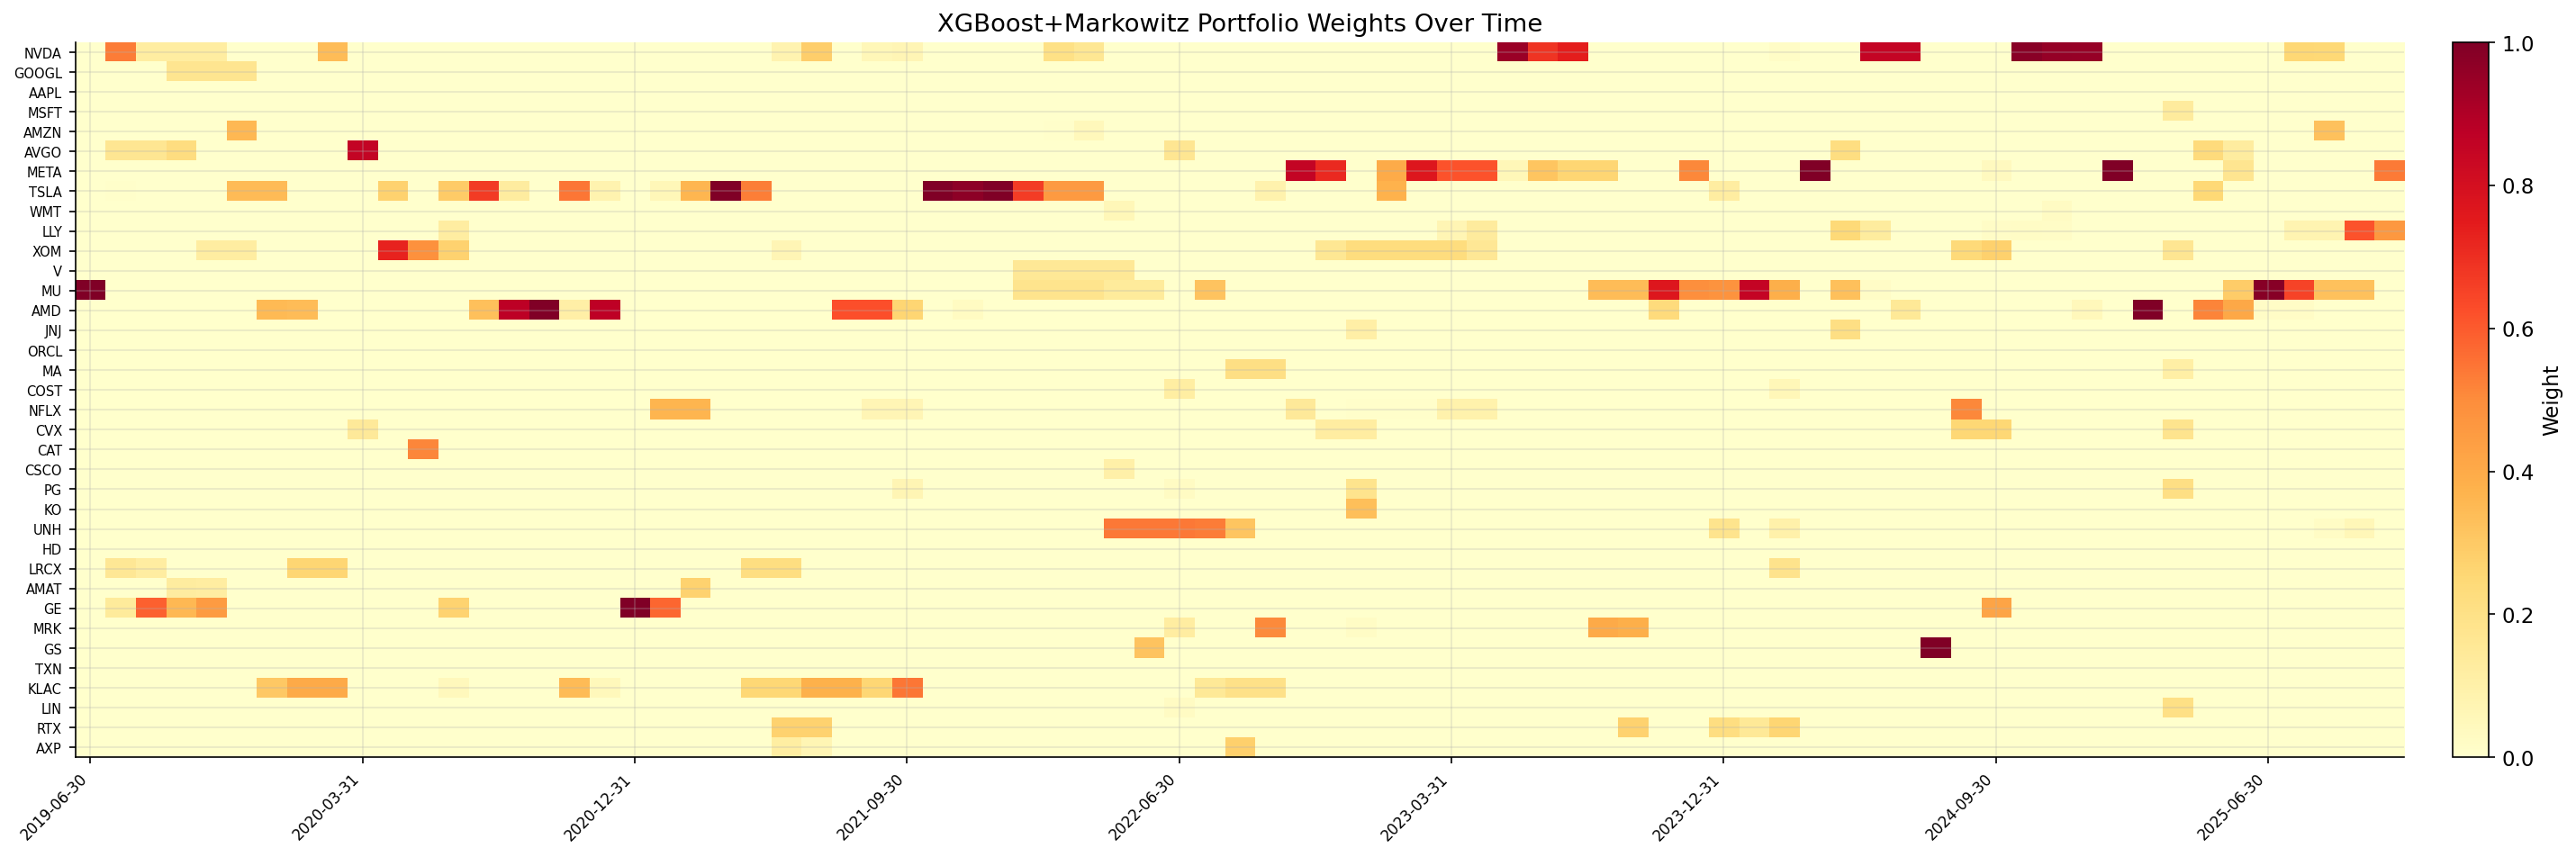

In [111]:
plot_weights_heatmap(
    weights_df,
    title='XGBoost+Markowitz Portfolio Weights Over Time',
)

### Portfolio Weight Allocation (Stacked Area)

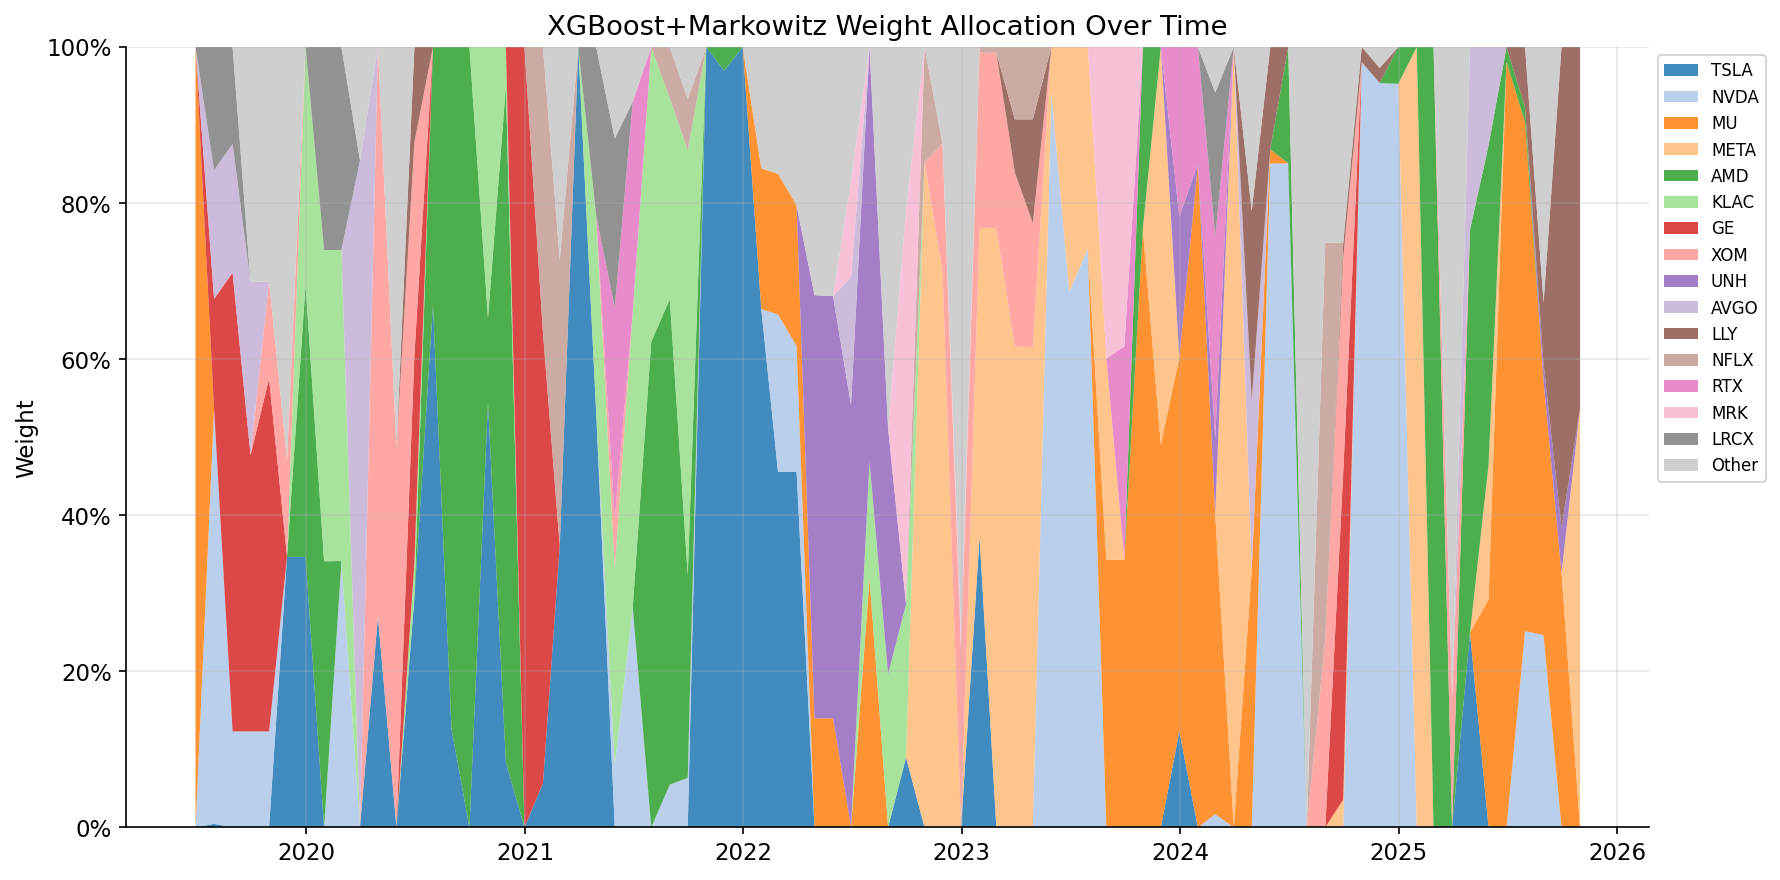

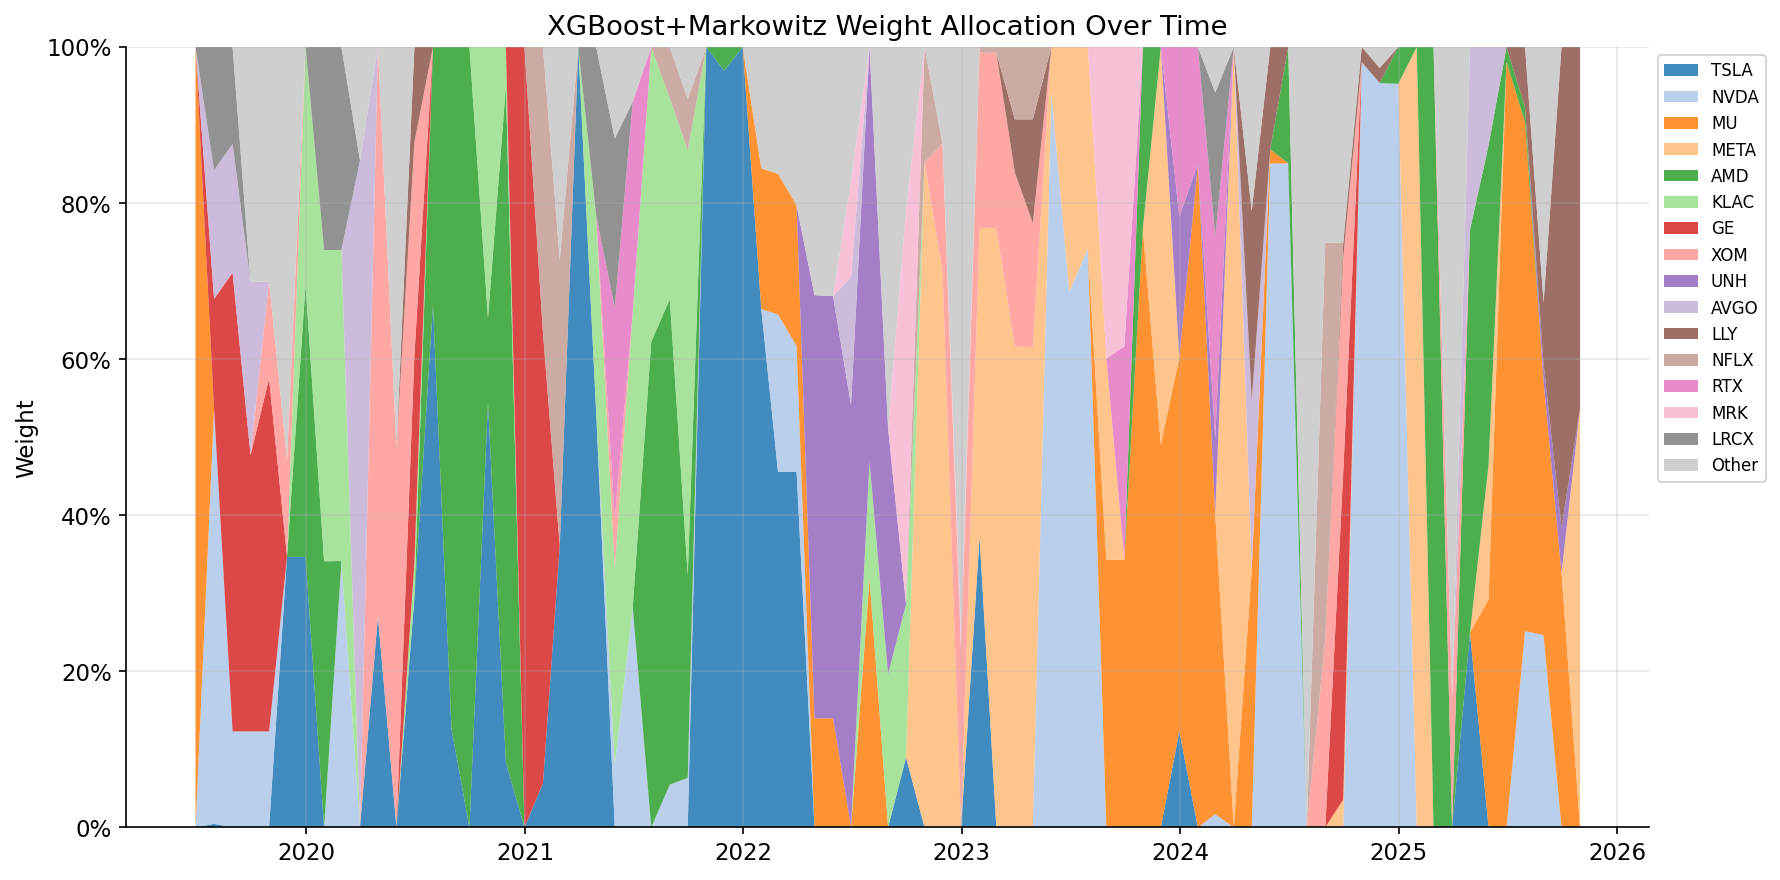

In [112]:
plot_weights_area(
    weights_df,
    title='XGBoost+Markowitz Weight Allocation Over Time',
    top_n=15,
)